# VAR 

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from tqdm import tqdm_notebook
from itertools import product

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [29]:
plt.rcParams['figure.figsize'] = [10, 7.5]

## United States Macroeconomic Dataset 

In [30]:
macro_data = sm.datasets.macrodata.load_pandas()
macro_data = macro_data.data
macro_data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


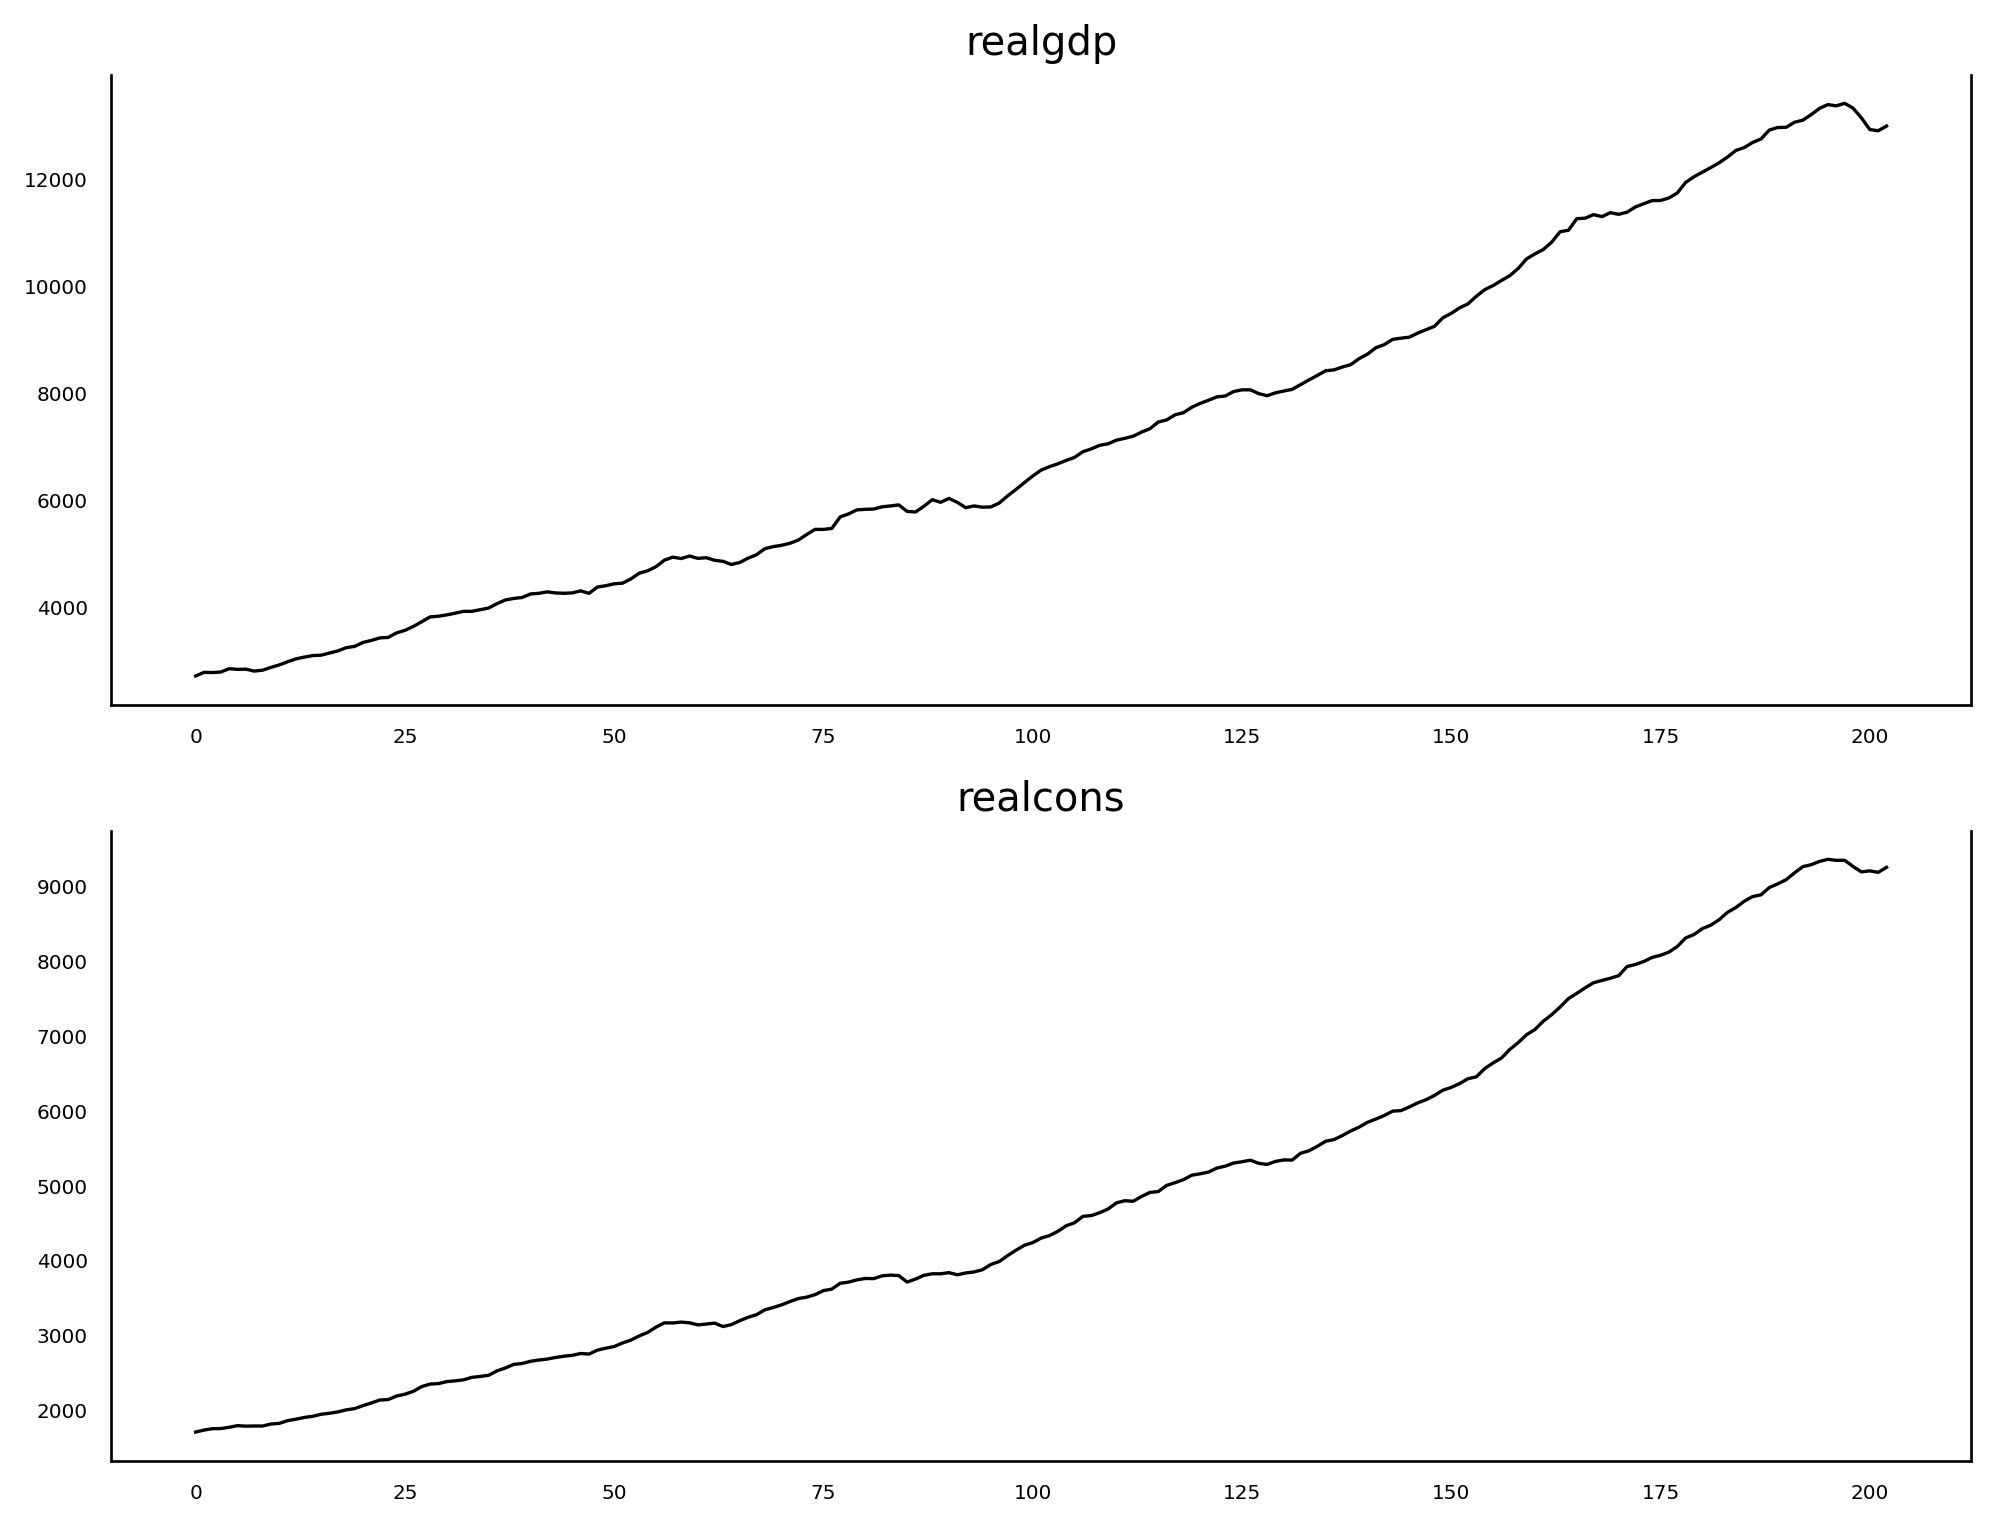

In [31]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(macro_data['realgdp'], color='black', linewidth=1)
ax1.set_title('realgdp')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(macro_data['realcons'], color='black', linewidth=1)
ax2.set_title('realcons')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)
plt.show()

In [32]:
ad_fuller_result_1 = adfuller(macro_data['realgdp'].diff()[1:])

print('realgdp')
print(f'ADF Statistic: {ad_fuller_result_1[0]}')
print(f'p-value: {ad_fuller_result_1[1]}')

print('\n---------------------\n')

ad_fuller_result_2 = adfuller(macro_data['realcons'].diff()[1:])

print('realcons')
print(f'ADF Statistic: {ad_fuller_result_2[0]}')
print(f'p-value: {ad_fuller_result_2[1]}')

realgdp
ADF Statistic: -6.305695561658104
p-value: 3.327882187668259e-08

---------------------

realcons
ADF Statistic: -4.204306080845247
p-value: 0.0006479282158627571


In [33]:
def optimize_VAR(endog):
    """
        Returns a dataframe with parameters and corresponding MSE
        
        endog - observed time series
    """
    
    results = []
    
    for i in tqdm_notebook(range(15)):
        try:
            model = VARMAX(endog, order=(i, 0)).fit(dips=False)
        except:
            continue
            
        mse = model.mse
        results.append([i, mse])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['p', 'mse']
    
    result_df = result_df.sort_values(by='mse', ascending=True).reset_index(drop=True)
    
    return result_df

In [34]:
endog = macro_data[['realgdp', 'realcons']]

result_df = optimize_VAR(endog)
result_df

  0%|          | 0/15 [00:00<?, ?it/s]

,p,mse
0,12,1.339300e+05
1,11,1.444468e+05
2,13,1.446913e+05
3,9,1.617550e+05
4,8,1.651782e+05
5,10,1.672845e+05
6,6,1.716751e+05
7,5,1.755136e+05
8,4,1.806344e+05
9,3,3.581781e+05


In [35]:
best_model = VARMAX(endog, order=(12,0))
res = best_model.fit(disp=False)
print(res.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realgdp', 'realcons']   No. Observations:                  203
Model:                             VAR(12)   Log Likelihood               -1983.679
                               + intercept   AIC                           4073.357
Date:                     Wed, 16 Sep 2026   BIC                           4248.957
Time:                             11:04:35   HQIC                          4144.398
Sample:                                  0                                         
                                     - 203                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.14, 0.25   Jarque-Bera (JB):           5.41, 9.53
Prob(Q):                        0.71, 0.61   Prob(JB):                   0.07, 0.01
Heteroskedasticity (H):         1.73, 2.56   Skew:                       0.3

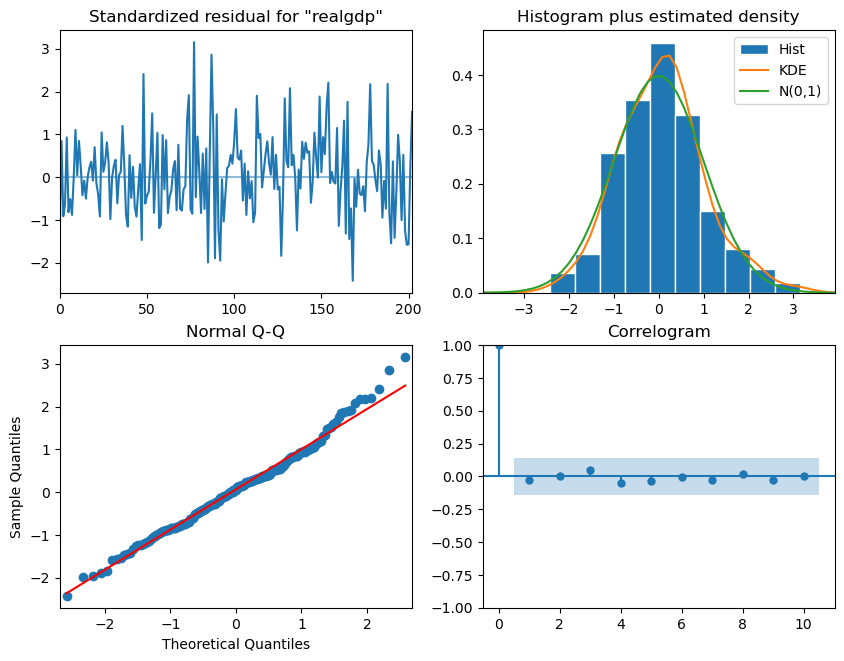

In [36]:
res.plot_diagnostics()

In [37]:
n_forecast = 3
predict = res.get_prediction(end=best_model.nobs + n_forecast)
idx = np.arange(len(predict.predicted_mean))

predict.predicted_mean.tail(3)

,realgdp,realcons
204,13173.018044,9298.974886
205,13201.823317,9298.818345
206,13241.295327,9301.159296


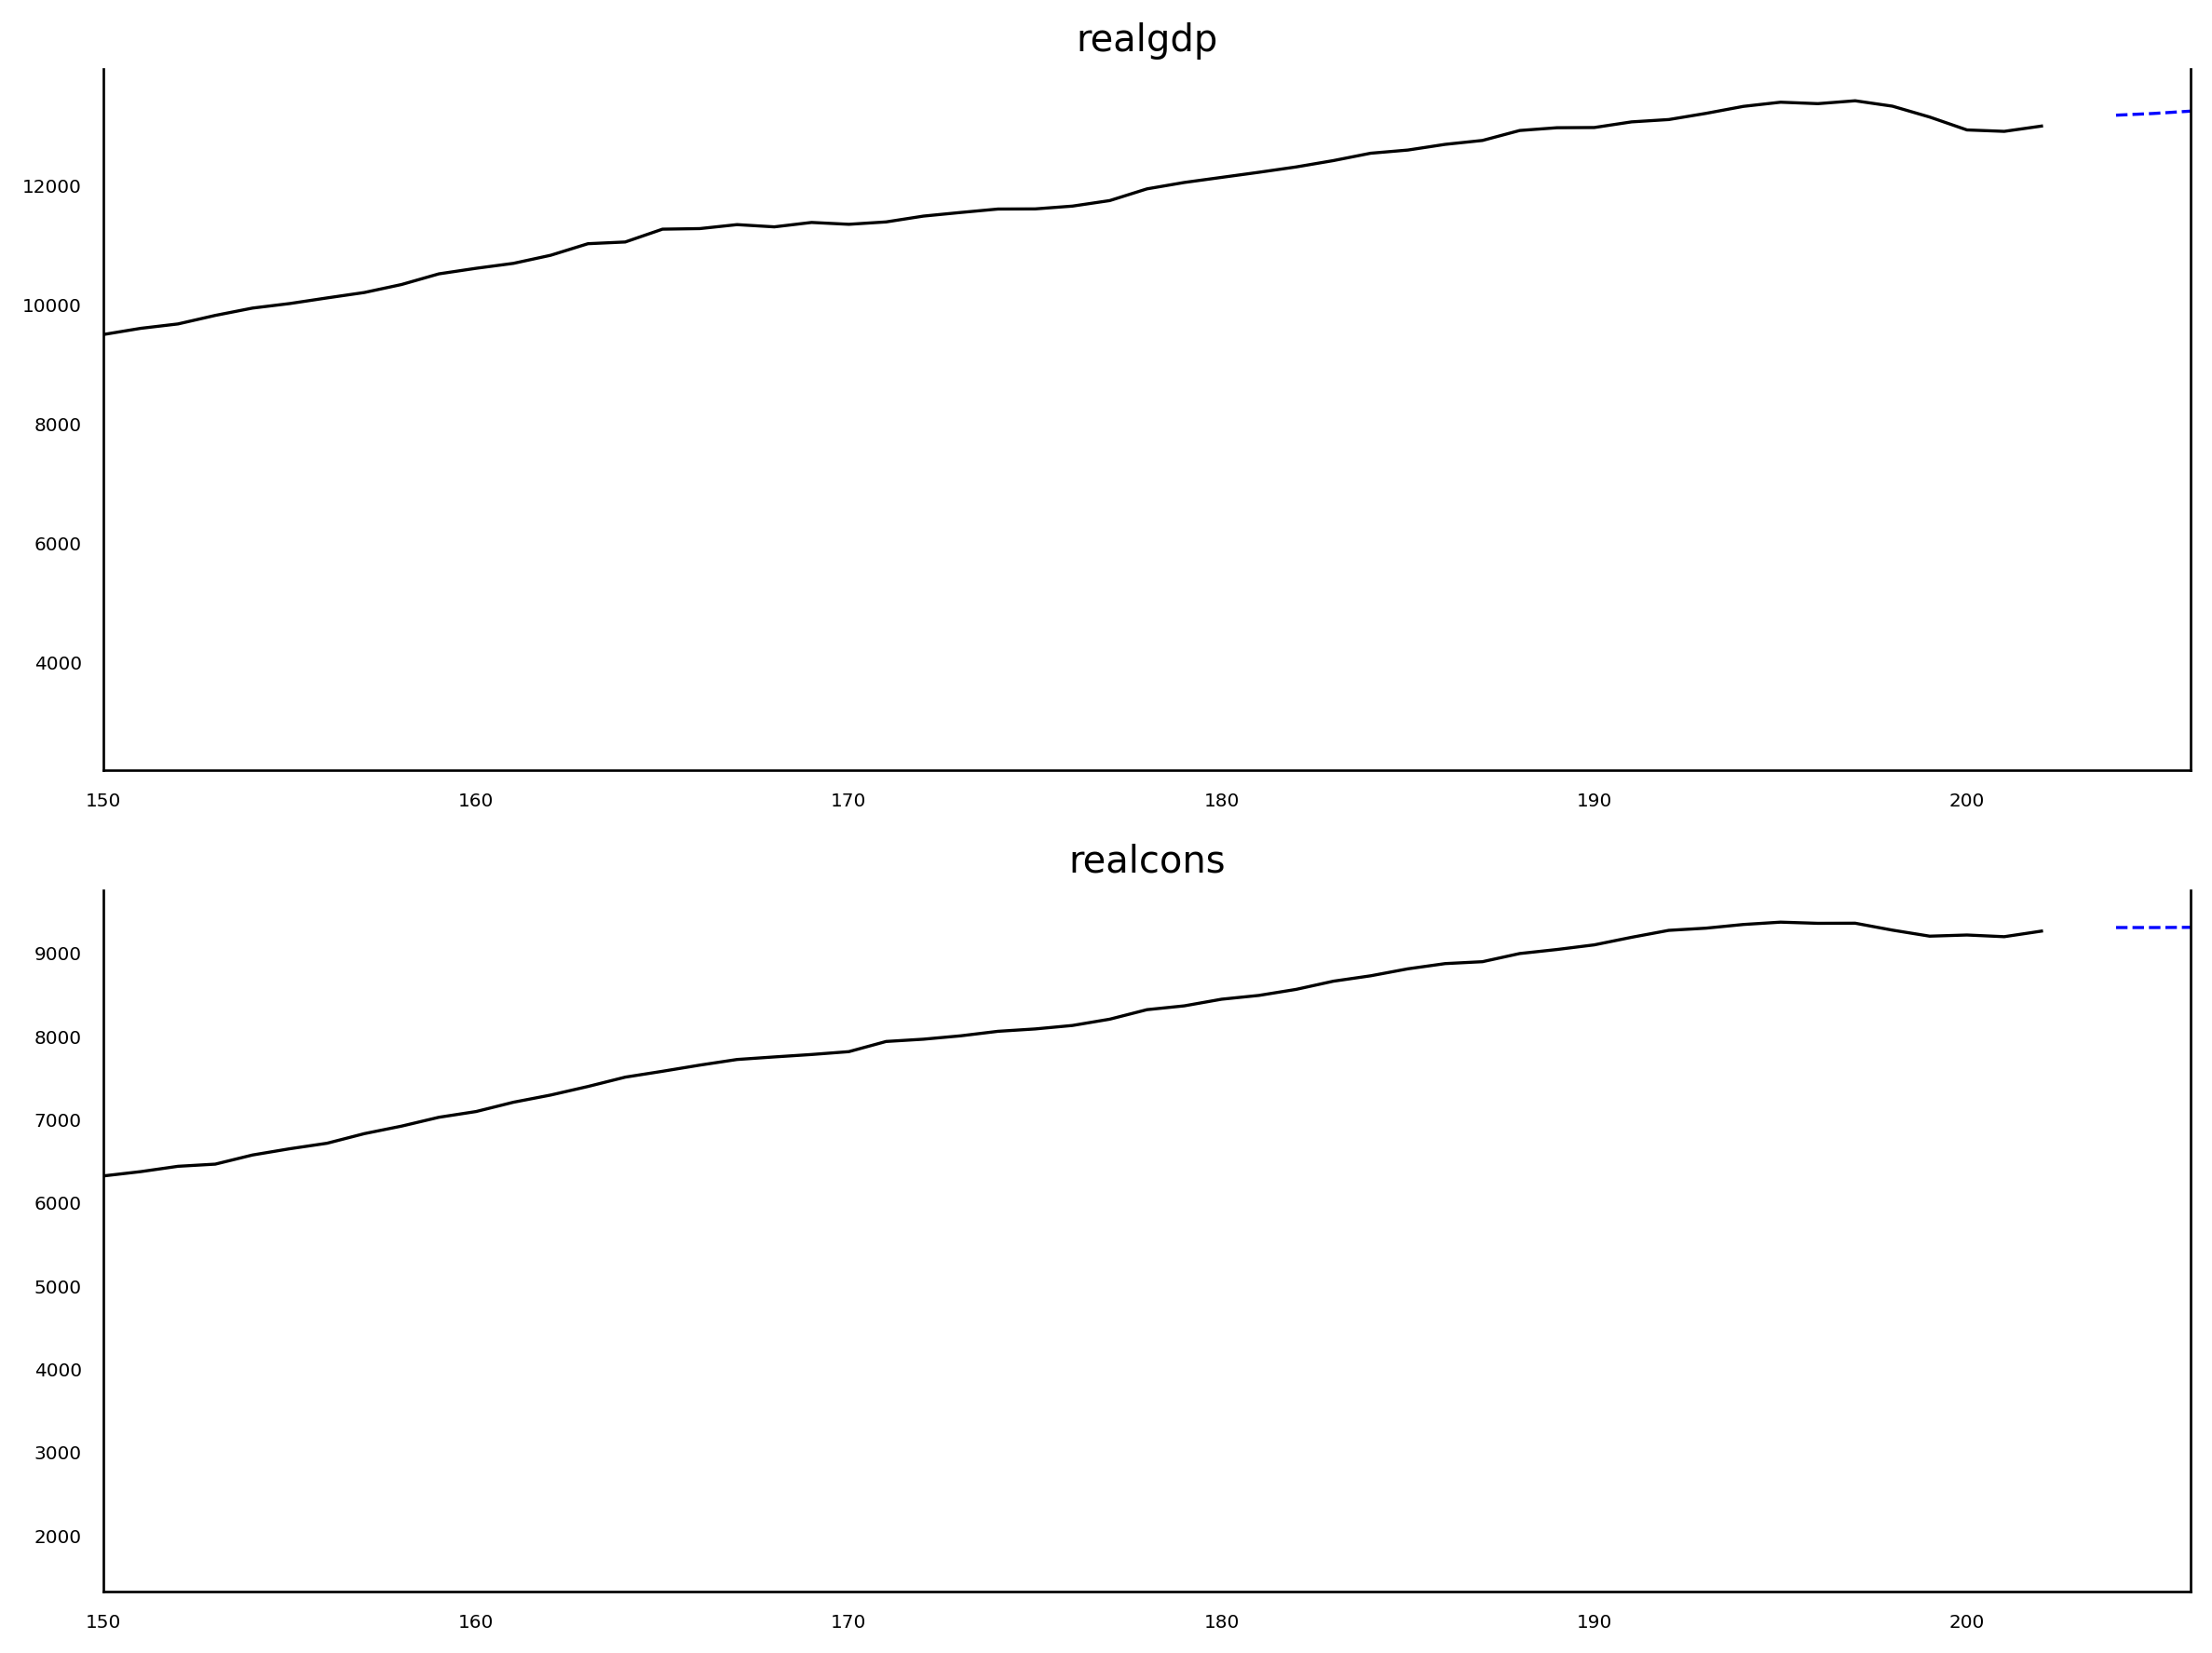

In [39]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(macro_data['realgdp'], color='black', linewidth=1)
ax1.plot(idx[-n_forecast:], 
         predict.predicted_mean['realgdp'][-n_forecast:], 
         color='blue', 
         ls='--',
         linewidth=1)
ax1.set_title('realgdp')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.set_xlim(150, 206)
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(macro_data['realcons'], color='black', linewidth=1)
ax2.plot(idx[-n_forecast:], 
         predict.predicted_mean['realcons'][-n_forecast:], 
         color='blue', 
         ls='--',
         linewidth=1)
ax2.set_title('realcons')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.set_xlim(150, 206)
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

In [40]:
help(grangercausalitytests)

Help on function grangercausalitytests in module statsmodels.tsa.stattools._stattools:

grangercausalitytests(x, maxlag, addconst=True)
    Four tests for Granger non-causality of 2 time series

    All four tests give similar results. `params_ftest` and `ssr_ftest` are
    equivalent based on F test which is identical to lmtest:grangertest in R.

    Parameters
    ----------
    x : array_like
        The data for testing whether the time series in the second column Granger
        causes the time series in the first column. Missing values are not
        supported.
    maxlag : int or sequence of int
        If an integer, computes the test for all lags up to maxlag. If a
        sequence, computes the tests only for the lags in maxlag.
    addconst : bool, optional
        Include a constant in the model.

    Returns
    -------
    dict
        All test results, dictionary keys are the number of lags. For each
        lag the values are a tuple, with the first element a dictionar

In [41]:
print('realcons causes realgdp?\n')
print('------------------')
grangercausalitytests
granger_1 = grangercausalitytests(macro_data[['realgdp', 'realcons']].diff()[1:], [12] )
print(granger_1)
print('\nrealgdp causes realcons?\n')
print('------------------')
granger_2 = grangercausalitytests(macro_data[['realcons', 'realgdp']].diff()[1:], [12])
print(granger_2)


realcons causes realgdp?

------------------
{np.int64(12): ({'ssr_ftest': (np.float64(6.114406346657365), np.float64(7.966166675031257e-09), np.float64(165.0), np.int64(12)), 'ssr_chi2test': (np.float64(84.48997860835631), np.float64(5.703751069927395e-13), np.int64(12)), 'lrtest': (np.float64(69.89922926093186), np.float64(3.345107460239541e-10), np.int64(12)), 'params_ftest': (np.float64(6.114406346657329), np.float64(7.966166675032357e-09), np.float64(165.0), 12.0)}, [<statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000001B584131B50>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000001B5843464B0>, array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0.,

In [42]:
granger_1.items()

dict_items([(np.int64(12), ({'ssr_ftest': (np.float64(6.114406346657365), np.float64(7.966166675031257e-09), np.float64(165.0), np.int64(12)), 'ssr_chi2test': (np.float64(84.48997860835631), np.float64(5.703751069927395e-13), np.int64(12)), 'lrtest': (np.float64(69.89922926093186), np.float64(3.345107460239541e-10), np.int64(12)), 'params_ftest': (np.float64(6.114406346657329), np.float64(7.966166675032357e-09), np.float64(165.0), 12.0)}, [<statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000001B584131B50>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000001B5843464B0>, array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0.,

In [43]:
list(granger_1.values())[0][0]['ssr_ftest'] # Estadístico de Prueba F, pvalor, df_numerador, df_denominador

(np.float64(6.114406346657365),
 np.float64(7.966166675031257e-09),
 np.float64(165.0),
 np.int64(12))

In [44]:
list(granger_1.values())[0][0]['ssr_chi2test'] # Estadístico de Prueba Chi cuadrado, pvalor, df

(np.float64(84.48997860835631),
 np.float64(5.703751069927395e-13),
 np.int64(12))

In [45]:
list(granger_2.values())[0][0]['ssr_ftest'] # Estadístico de Prueba F, pvalor, df_numerador, df_denominador

(np.float64(2.1147319756264045),
 np.float64(0.018472252768811717),
 np.float64(165.0),
 np.int64(12))

In [46]:
list(granger_2.values())[0][0]['ssr_chi2test'] # Estadístico de Prueba Chi cuadrado, pvalor, df

(np.float64(29.221750935928497),
 np.float64(0.0036519022541458075),
 np.int64(12))

In [47]:
def granger_to_df(data, maxlag, test="ssr_ftest"):
    """
    Run grangercausalitytests and return a tidy DataFrame.
    test : one of 'ssr_ftest', 'ssr_chi2test', 'lrtest', 'params_ftest'
    """
    res = grangercausalitytests(data, maxlag)
    dicti = list(res.values())[0][0][test]
    rows = []
    if (test=="ssr_ftest"):
        rows.append({
                "lag":      maxlag[0],
                "test":     test,
                "stat":     dicti[0],
                "p_value":  dicti[1],
                "df_denom": dicti[2],
                "df_num":   dicti[3]
            })
    else:
        rows.append({
                "lag":      maxlag[0],
                "test":     test,
                "stat":     dicti[0],
                "p_value":  dicti[1],
                "df": dicti[2]
            })
        
    
    return pd.DataFrame(rows).set_index("test")

In [48]:
granger_to_df(macro_data[['realgdp', 'realcons']].diff()[1:], [12], test="ssr_ftest")

,lag,stat,p_value,df_denom,df_num
test,,,,,
ssr_ftest,12,6.114406,7.966167e-09,165.0,12


In [49]:
granger_to_df(macro_data[[ 'realcons', 'realgdp']].diff()[1:], [12], test="ssr_ftest")

,lag,stat,p_value,df_denom,df_num
test,,,,,
ssr_ftest,12,2.114732,0.018472,165.0,12


In [50]:
granger_to_df(macro_data[['realgdp', 'realcons']].diff()[1:], [12], test="ssr_chi2test")

,lag,stat,p_value,df
test,,,,
ssr_chi2test,12,84.489979,5.703751e-13,12


In [51]:
granger_to_df(macro_data[['realcons', 'realgdp']].diff()[1:], [12], test="ssr_chi2test")

,lag,stat,p_value,df
test,,,,
ssr_chi2test,12,29.221751,0.003652,12


La hipótesis nula para `grangercausalitytests` es que la serie temporal de la segunda columna, x2, NO causa en el sentido de Granger a la serie temporal de la primera columna.
En este caso se rechaza esa hipótesis nula.

La hipótesis nula para las cuatro pruebas es que los coeficientes correspondientes a los valores pasados ​​de la segunda serie temporal son iguales a cero, cuando la primera serie es función de la segunda serie.

Entonces se concluye que las segundas columnas causan en el sentido Granger a las primeras columnas.

# VARMA

In [52]:
def optimize_VARMAXX(endog, parameters_list):
    """
        Returns a dataframe with parameters (p,d) and corresponding MSE
        
        endog - the observed variable
        parameters_list - list of (p,q) tuples
    """
    
    results = []
    
    for param in tqdm_notebook(parameters_list):
        try:
            model = VARMAX(endog, order=param).fit(disp=False)
        except:
            continue
    
        bic = model.bic
        results.append([param, bic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'bic']
    
    result_df = result_df.sort_values(by='bic', ascending=True).reset_index(drop=True)
    
    return result_df

In [53]:
endog = macro_data[['realgdp', 'realcons']]

p = range(0, 4, 1)
q = range(0, 4, 1)

parameters = product(p, q)
parameters_list = list(parameters)

result_df_VARMA = optimize_VARMAXX(endog, parameters_list)
result_df_VARMA

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",bic
0,"(3, 1)",4113.495510
1,"(3, 0)",4116.861749
2,"(3, 2)",4133.320658
3,"(3, 3)",4151.743363
4,"(1, 3)",5645.443522
5,"(1, 1)",5741.266497
6,"(0, 3)",6131.820607
7,"(0, 1)",6183.061455
8,"(0, 2)",6295.005144
9,"(2, 3)",6804.567020


In [54]:
best_model_VARMA = VARMAX(endog, order=(3,1))
res_VARMA = best_model_VARMA.fit(disp=False)
print(res_VARMA.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realgdp', 'realcons']   No. Observations:                  203
Model:                          VARMA(3,1)   Log Likelihood               -2000.959
                               + intercept   AIC                           4043.918
Date:                     Wed, 16 Sep 2026   BIC                           4113.496
Time:                             11:05:56   HQIC                          4072.066
Sample:                                  0                                         
                                     - 203                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.57, 0.01   Jarque-Bera (JB):          3.39, 10.83
Prob(Q):                        0.45, 0.94   Prob(JB):                   0.18, 0.00
Heteroskedasticity (H):         2.48, 2.98   Skew:                       0.1

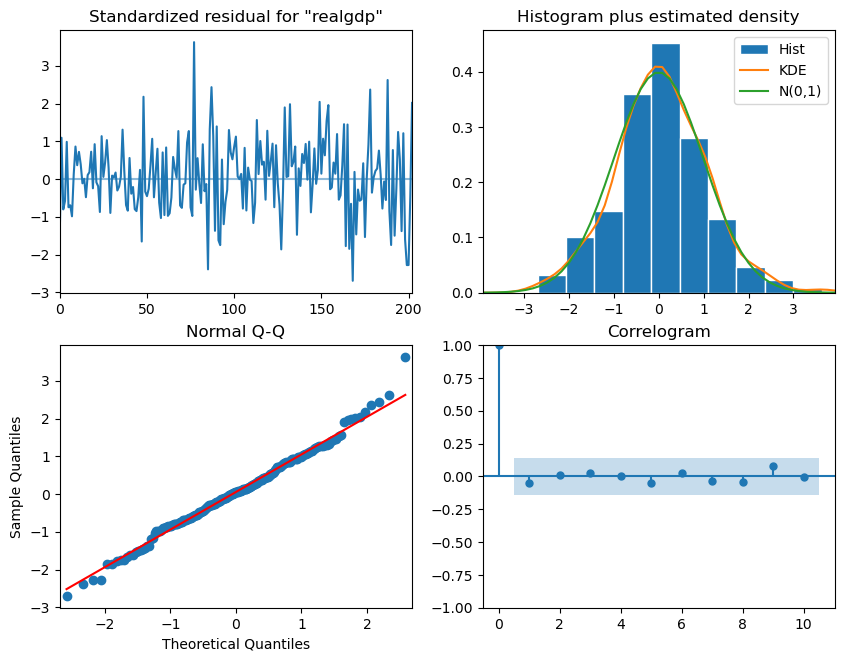

In [55]:
res_VARMA.plot_diagnostics()

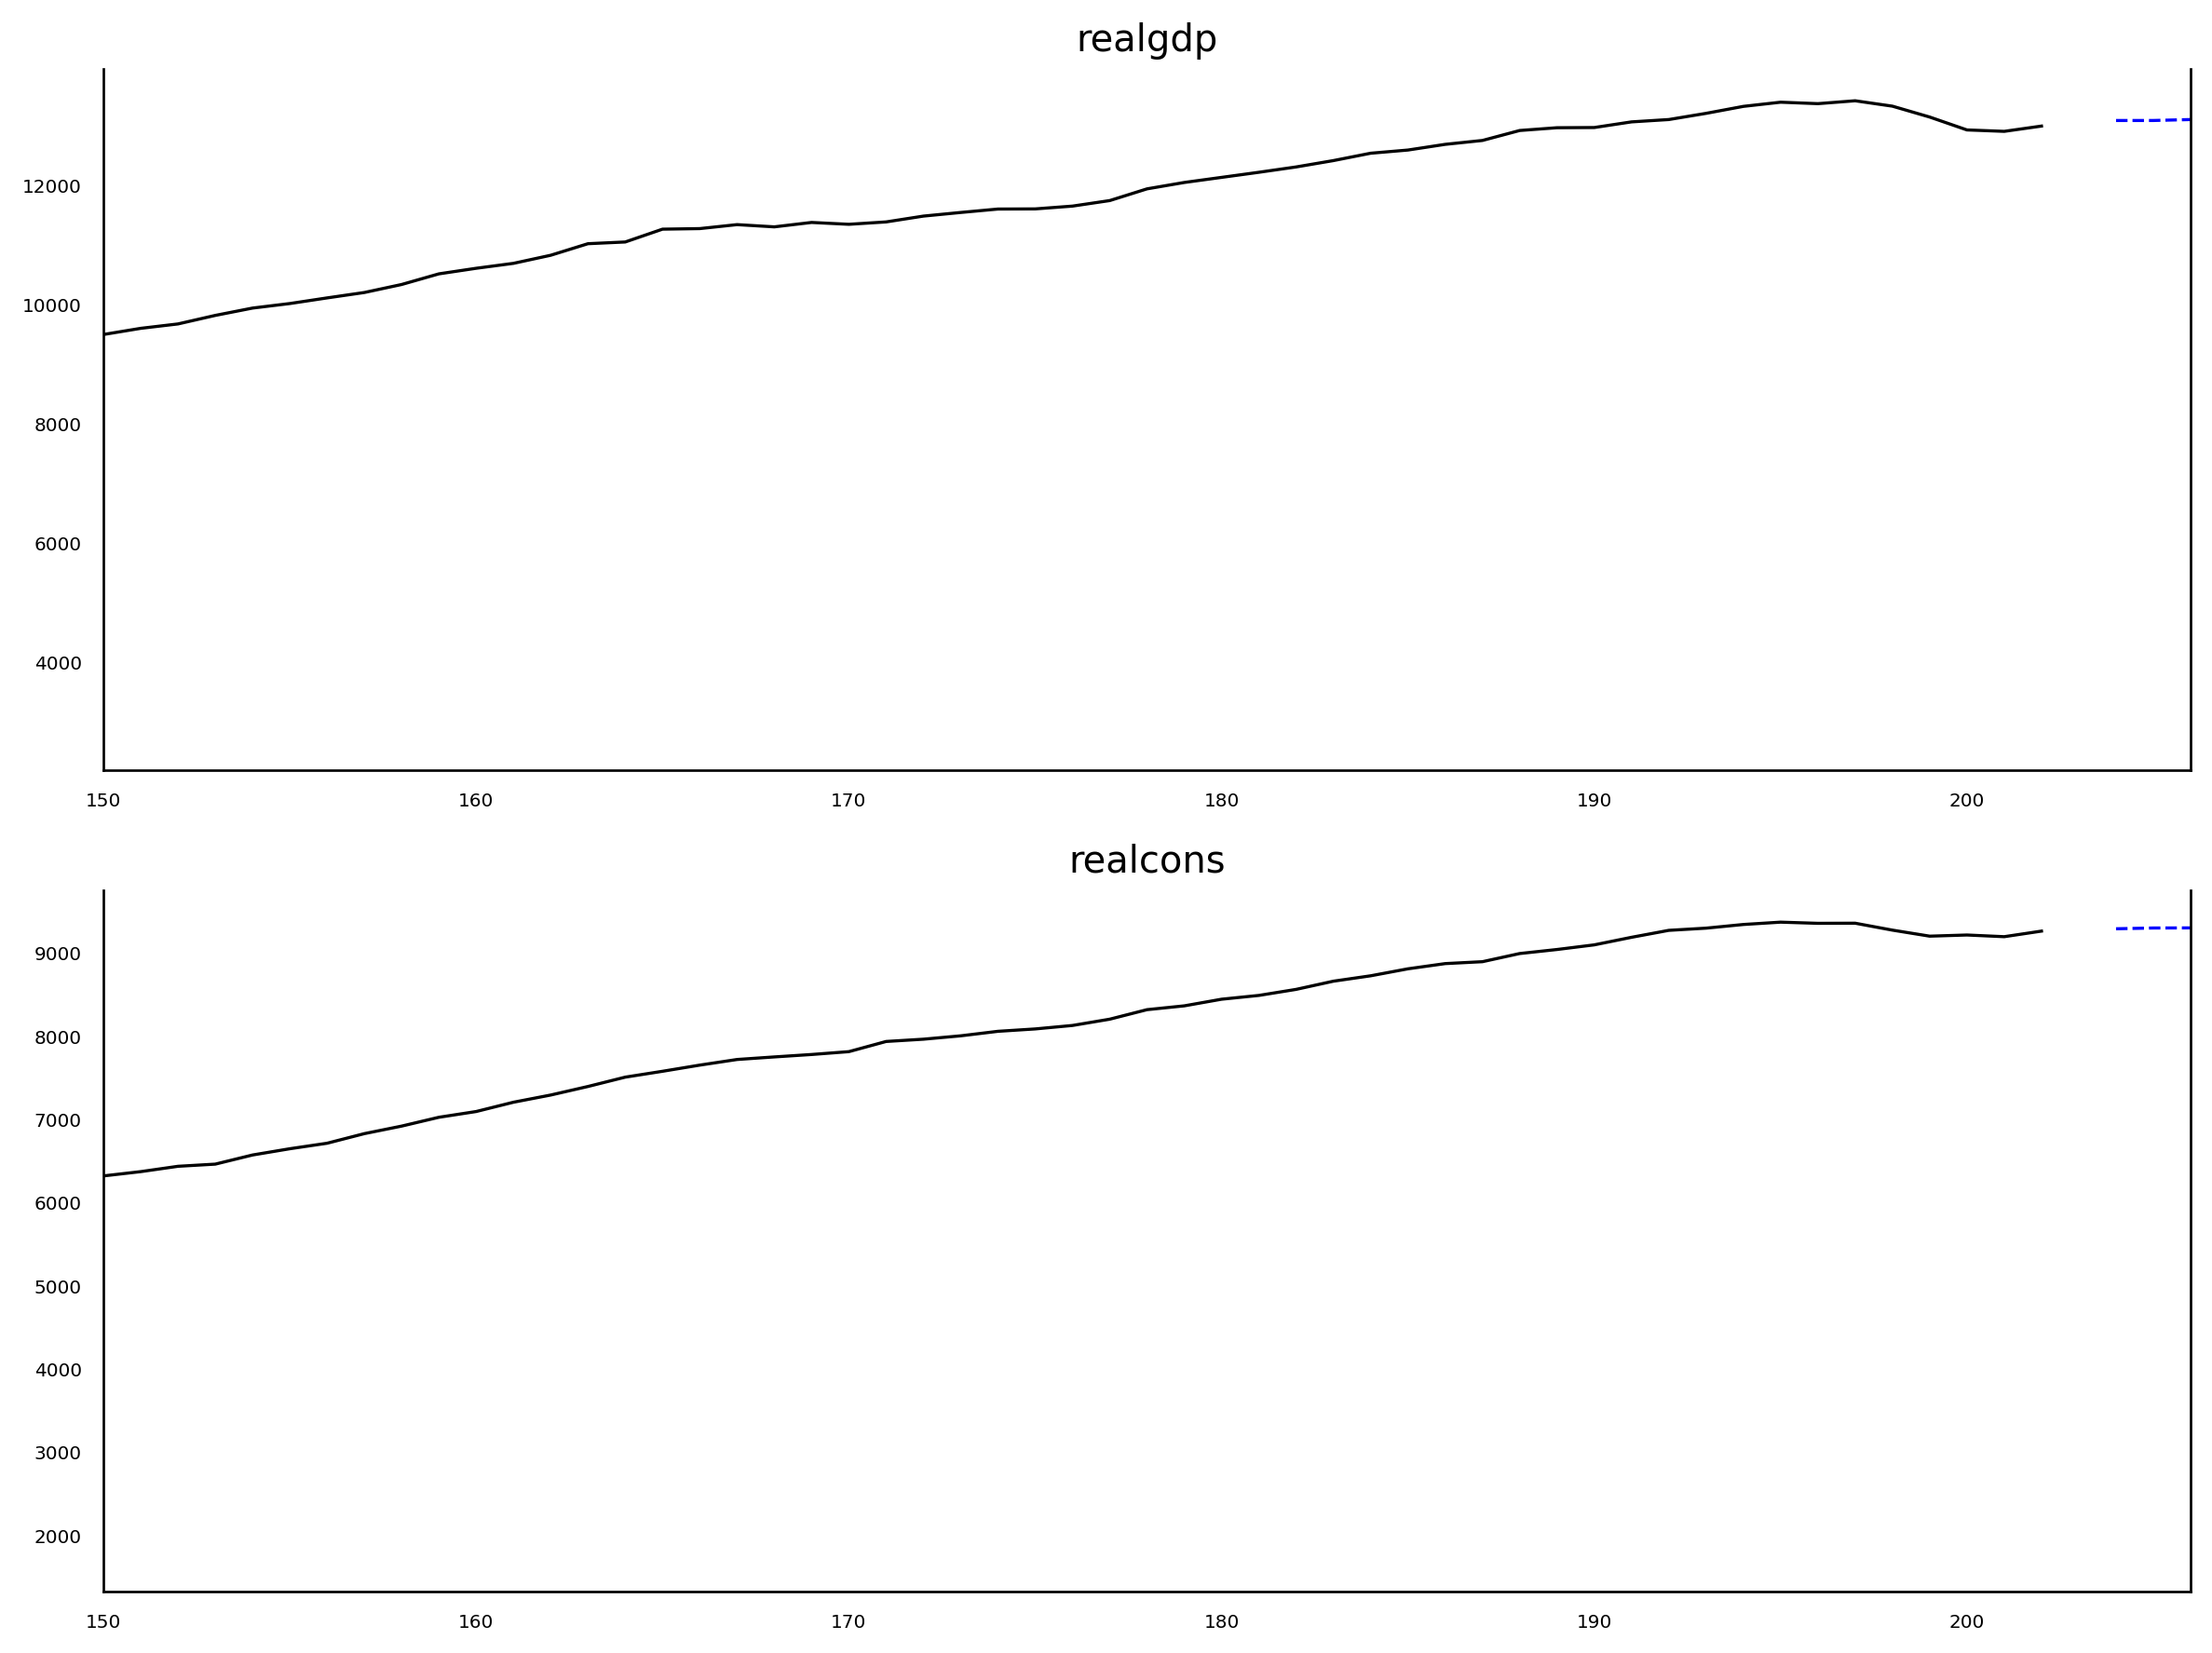

In [57]:
n_forecast = 3
predict = res_VARMA.get_prediction(end=best_model_VARMA.nobs + n_forecast)
idx = np.arange(len(predict.predicted_mean))

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(macro_data['realgdp'], color='black', linewidth=1)
ax1.plot(idx[-n_forecast:], 
         predict.predicted_mean['realgdp'][-n_forecast:], 
         color='blue', 
         ls='--',
         linewidth=1)
ax1.set_title('realgdp')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.set_xlim(150, 206)
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(macro_data['realcons'], color='black', linewidth=1)
ax2.plot(idx[-n_forecast:], 
         predict.predicted_mean['realcons'][-n_forecast:], 
         color='blue', 
         ls='--',
         linewidth=1)
ax2.set_title('realcons')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.set_xlim(150, 206)
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

In [58]:
best_model_VARMA = VARMAX(endog, order=(3,1))
res_VARMA = best_model_VARMA.fit(disp=False)
print(res_VARMA.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realgdp', 'realcons']   No. Observations:                  203
Model:                          VARMA(3,1)   Log Likelihood               -2000.959
                               + intercept   AIC                           4043.918
Date:                     Wed, 16 Sep 2026   BIC                           4113.496
Time:                             11:06:15   HQIC                          4072.066
Sample:                                  0                                         
                                     - 203                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.57, 0.01   Jarque-Bera (JB):          3.39, 10.83
Prob(Q):                        0.45, 0.94   Prob(JB):                   0.18, 0.00
Heteroskedasticity (H):         2.48, 2.98   Skew:                       0.1

El modelo de `y=realcons` $ en función de `x=realgdp` es:

$$y_t = -7.3439 + 0.1372x_{t-1}+ 1.8093 y_{t-1} -0.2107x_{t-2}-0.8022 y_{t-2}+0.0928x_{t-3}-0.0338 y_{t-3} + w_{y,t} -0.1468w_{x,t-1}-0.5556  w_{y,t-1} $$

El modelo de `y=realcons` $ en función de `x=realgdp` es:

$$y_t = 33.1961 + 1.4994y_{t-1}+ 0.4877 x_{t-1} -0.6781y_{t-2}+0.4293 x_{t-2}-0.7506y_{t-3}+0.0299 x_{t-3} + w_{y,t} -0.5786w_{y,t-1}-0.1468   w_{x,t-1} $$

$$ E[w_{realgdp,t}^2]=47.2147^2$$
$$ E[w_{realcons,t}^2]=25.0249^2$$
$$ E[w_{realcons,t}w_{realgdp,t}]=15.9084^2$$

# Ejemplo adicional VARMA

In [59]:
pip install pandas-datareader

Note: you may need to restart the kernel to use updated packages.


In [60]:
import pandas_datareader as web
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from tqdm import tqdm_notebook
from itertools import product

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


In [61]:
plt.rcParams['figure.figsize'] = [10, 7.5]

In [62]:
pip install yfinance pandas

Note: you may need to restart the kernel to use updated packages.


In [63]:
import yfinance as yf

# Download historical data for a stock
df = yf.download("GOOG", start="2025-06-01", end="2026-01-01")
#df = df.filter(['High', 'Low'])
df
# View the pandas DataFrame
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            GOOG        GOOG        GOOG        GOOG      GOOG
Date                                                                
2025-06-02  169.570831  170.259587  167.858898  168.217210  24742900
2025-06-03  166.923325  169.003517  165.898142  168.072906  25386700
2025-06-04  168.595444  168.784555  167.007924  167.490650  18508700
2025-06-05  169.013458  171.551500  168.555625  170.814966  25375400
2025-06-06  174.099487  175.005222  171.491782  171.491782  22258100


In [64]:
df = df[['High','Low']]

In [65]:
df

Price,High,Low
Ticker,GOOG,GOOG
Date,,
2025-06-02,170.259587,167.858898
2025-06-03,169.003517,165.898142
2025-06-04,168.784555,167.007924
2025-06-05,171.551500,168.555625
2025-06-06,175.005222,171.491782
...,...,...
2025-12-24,315.672312,312.708111
2025-12-26,315.941760,313.107311


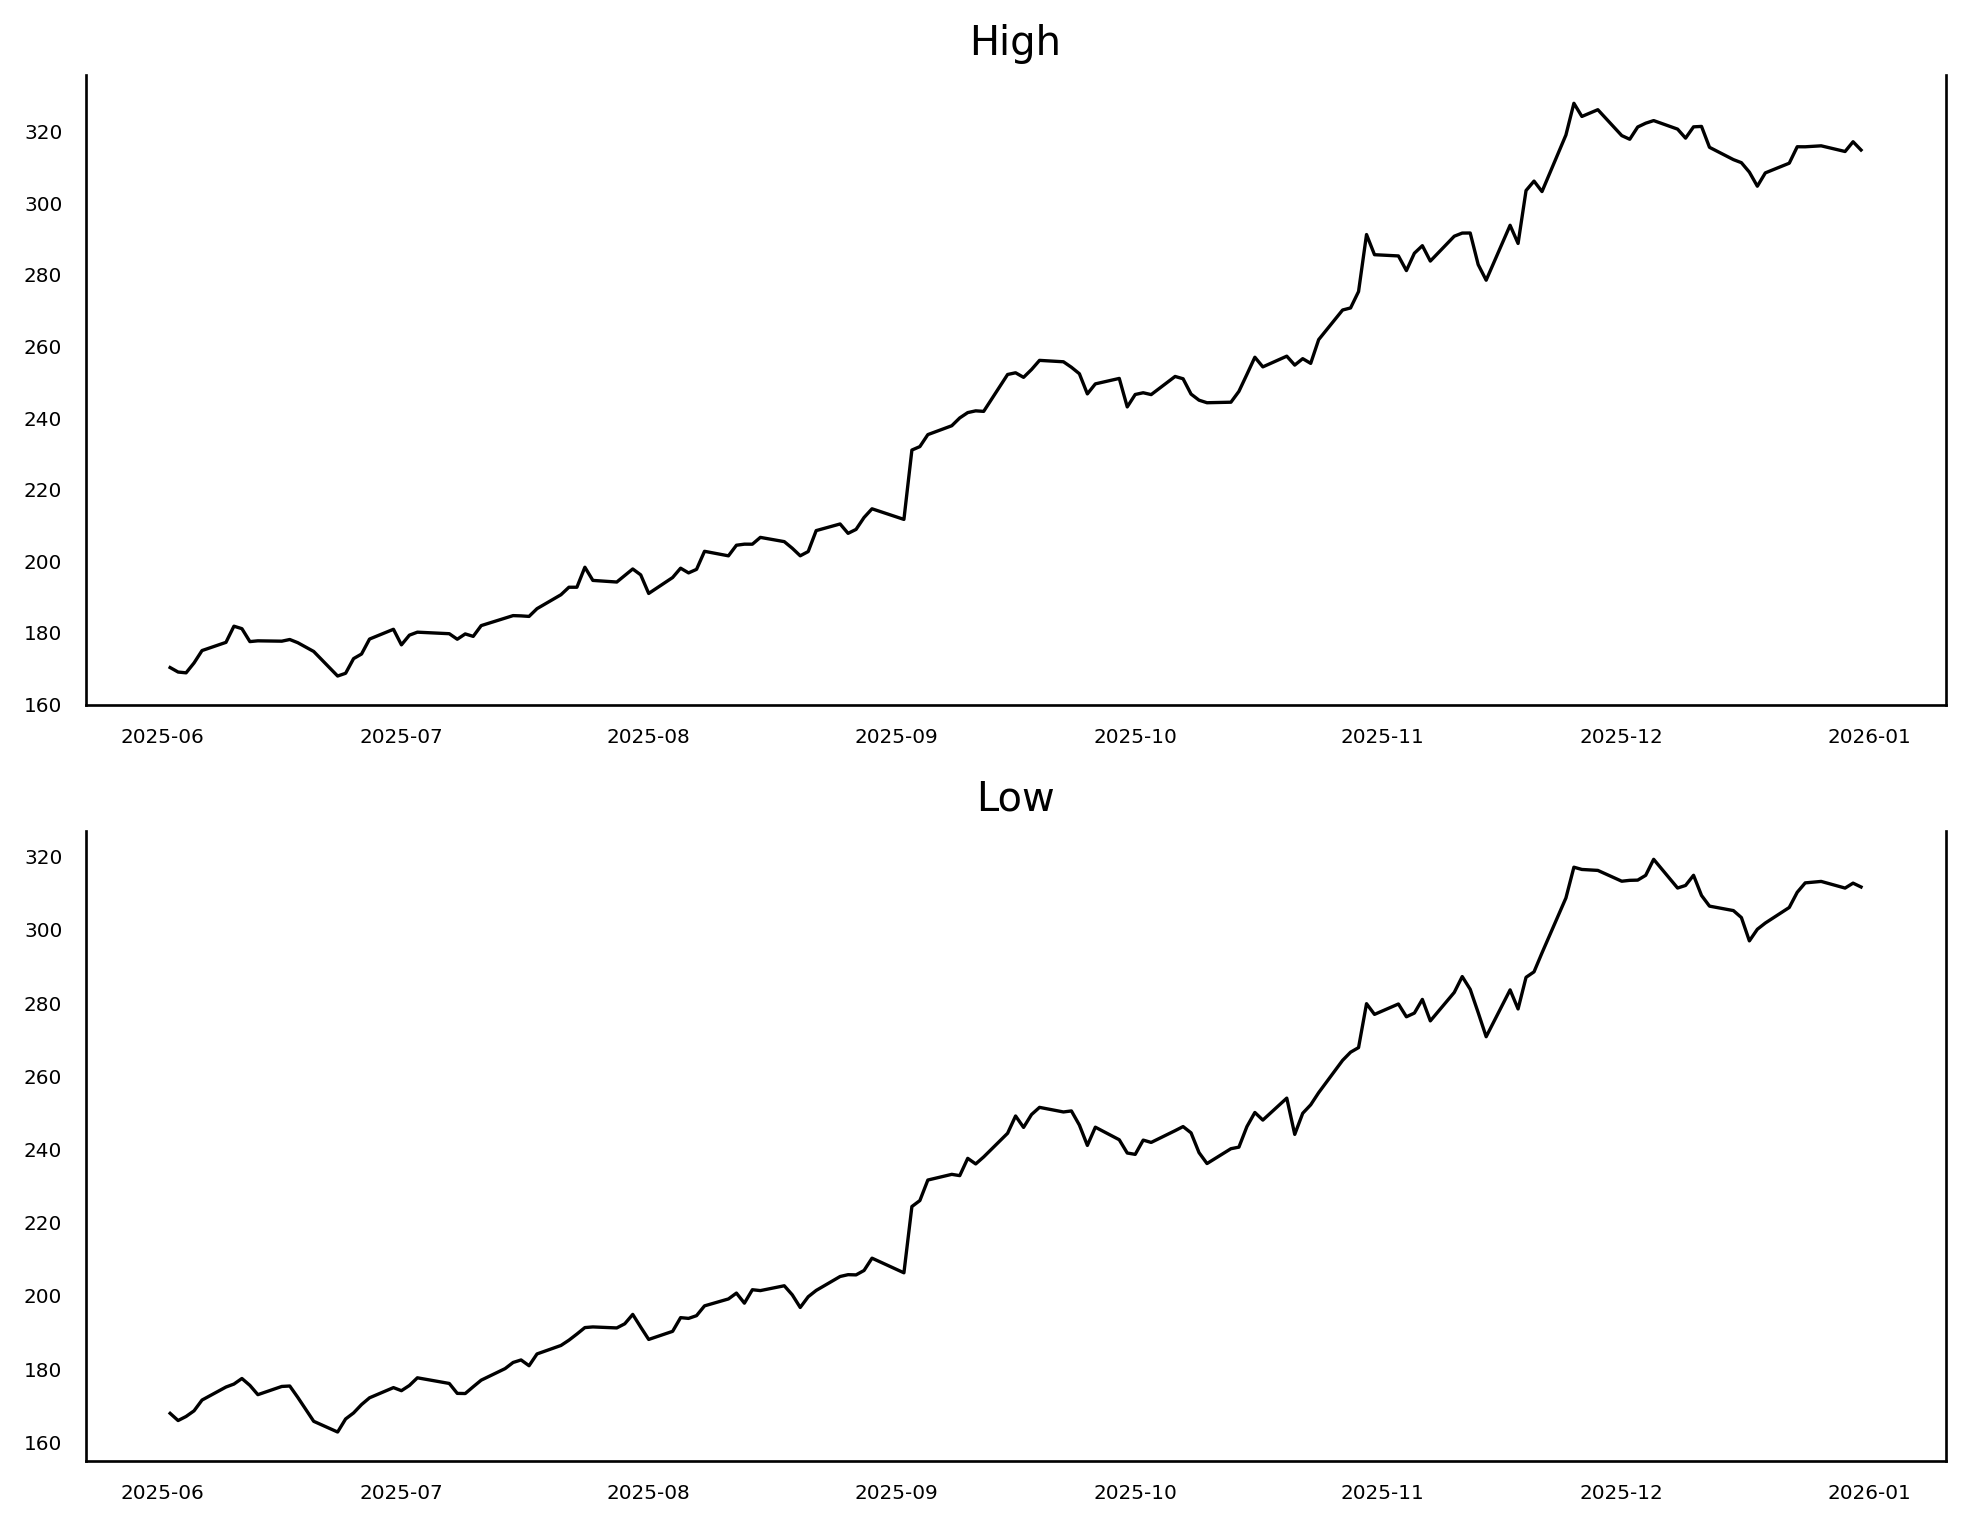

In [66]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(df['High'], color='black', linewidth=1)
ax1.set_title('High')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(df['Low'], color='black', linewidth=1)
ax2.set_title('Low')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)
plt.show()

In [67]:
ad_fuller_result_1 = adfuller(df['High'].diff()[1:])

print('High')
print(f'ADF Statistic: {ad_fuller_result_1[0]}')
print(f'p-value: {ad_fuller_result_1[1]}')

print('\n---------------------\n')

ad_fuller_result_2 = adfuller(df['Low'].diff()[1:])

print('Low')
print(f'ADF Statistic: {ad_fuller_result_2[0]}')
print(f'p-value: {ad_fuller_result_2[1]}')

High
ADF Statistic: -12.968599444612769
p-value: 3.1153842308461588e-24

---------------------

Low
ADF Statistic: -12.557410636515462
p-value: 2.1392518271710048e-23


In [68]:
def optimize_VARMAXX(endog, parameters_list):
    """
        Returns a dataframe with parameters (p,d) and corresponding MSE
        
        endog - the observed variable
        parameters_list - list of (p,q) tuples
    """
    
    results = []
    
    for param in tqdm_notebook(parameters_list):
        try:
            model = VARMAX(endog, order=param).fit(disp=False)
        except:
            continue
    
        mse = model.mse
        results.append([param, mse])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'mse']
    
    result_df = result_df.sort_values(by='mse', ascending=True).reset_index(drop=True)
    
    return result_df

In [69]:
endog = df

p = range(0, 4, 1)
q = range(0, 4, 1)

parameters = product(p, q)
parameters_list = list(parameters)

# Option B: Force the regular interval (highly recommended if inferred_freq is None):
#endog = endog.asfreq("D")  # Replac

result_df_VARMA = optimize_VARMAXX(endog, parameters_list)
result_df_VARMA

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",mse
0,"(1, 3)",82.481895
1,"(3, 1)",89.448229
2,"(2, 1)",91.819636
3,"(3, 3)",94.808169
4,"(2, 3)",94.938006
5,"(3, 0)",95.957655
6,"(2, 2)",97.165475
7,"(3, 2)",97.833549
8,"(1, 2)",98.659700
9,"(2, 0)",99.123451


In [70]:
endog

Price,High,Low
Ticker,GOOG,GOOG
Date,,
2025-06-02,170.259587,167.858898
2025-06-03,169.003517,165.898142
2025-06-04,168.784555,167.007924
2025-06-05,171.551500,168.555625
2025-06-06,175.005222,171.491782
...,...,...
2025-12-24,315.672312,312.708111
2025-12-26,315.941760,313.107311


In [71]:
endog = endog.asfreq("D")  # Replac
best_model_VARMA = VARMAX(endog, order=(1,3))
res_VARMA = best_model_VARMA.fit(disp=False)
print(res_VARMA.summary())

                               Statespace Model Results                              
Dep. Variable:     ['High_GOOG', 'Low_GOOG']   No. Observations:                  213
Model:                            VARMA(1,3)   Log Likelihood                -735.373
                                 + intercept   AIC                           1512.746
Date:                       Wed, 16 Sep 2026   BIC                           1583.333
Time:                               11:12:14   HQIC                          1541.272
Sample:                           06-02-2025                                         
                                - 12-31-2025                                         
Covariance Type:                         opg                                         
Ljung-Box (L1) (Q):               nan, nan   Jarque-Bera (JB):        254.48, 20.69
Prob(Q):                          nan, nan   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         4.07, 2.86   Skew:        

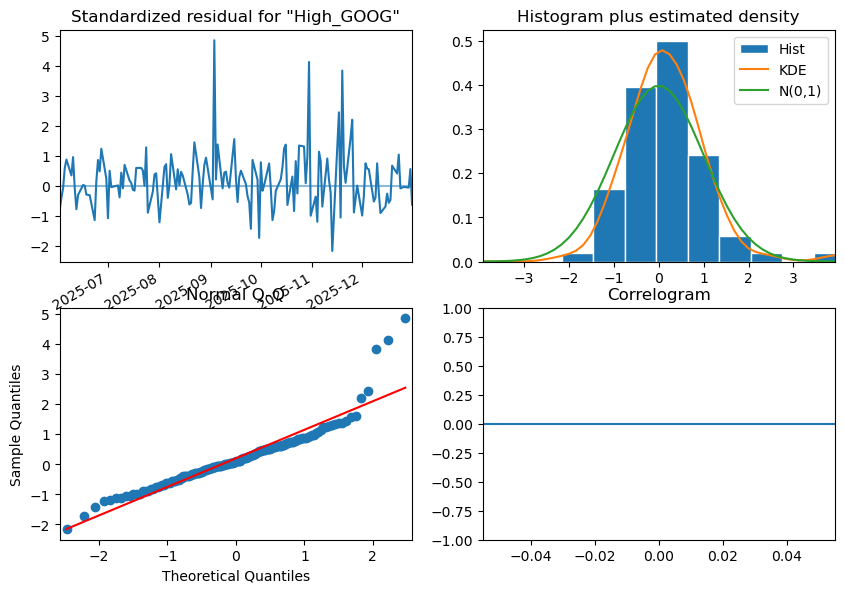

In [72]:
res_VARMA.plot_diagnostics()

In [73]:
res_VARMA.resid

,High_GOOG,Low_GOOG
Date,,
2025-06-02,-59.842961,-57.405806
2025-06-03,-1.542048,-1.544496
2025-06-04,-0.232490,1.052526
2025-06-05,2.387351,2.310597
2025-06-06,3.476939,3.011493
...,...,...
2025-12-27,NaN,NaN
2025-12-28,NaN,NaN
2025-12-29,-0.304539,1.969983


In [74]:
res_VARMA.resid['High_GOOG'][1:].dropna()

Date
2025-06-03   -1.542048
2025-06-04   -0.232490
2025-06-05    2.387351
2025-06-06    3.476939
2025-06-09    2.305940
                ...   
2025-12-24   -0.293696
2025-12-26   -0.126252
2025-12-29   -0.304539
2025-12-30    2.295415
2025-12-31   -2.472612
Name: High_GOOG, Length: 147, dtype: float64

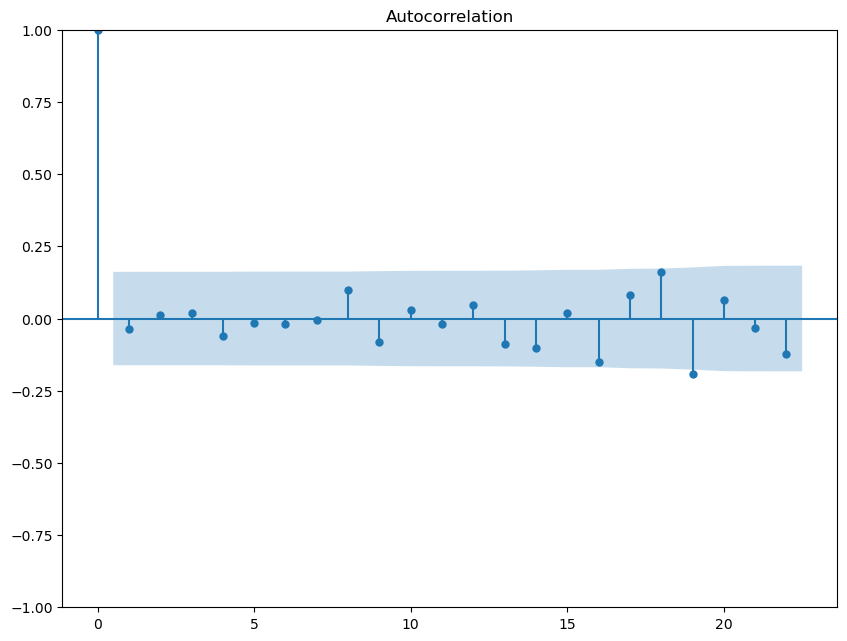

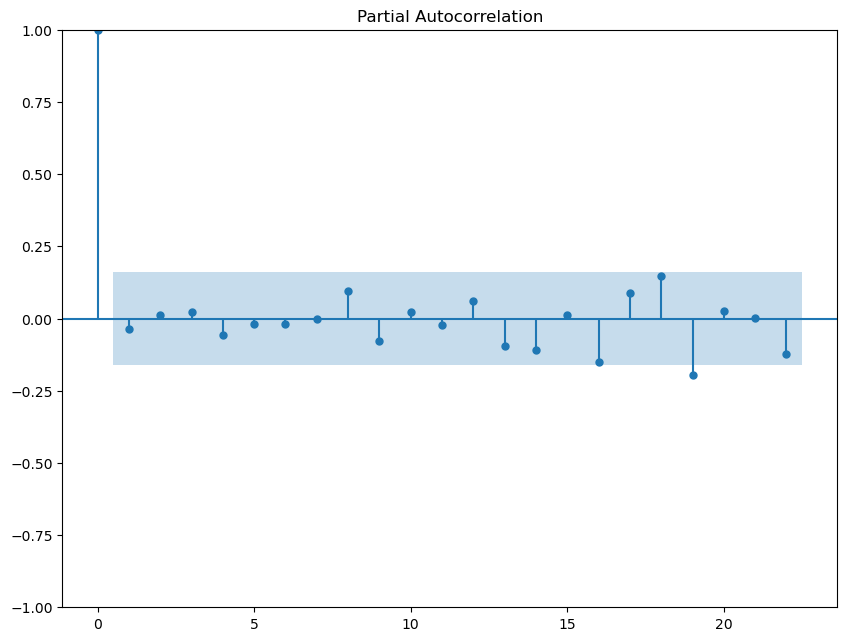

In [76]:
plot_acf(res_VARMA.resid['High_GOOG'][1:].dropna())
plot_pacf(res_VARMA.resid['High_GOOG'][1:].dropna())
plt.show()

In [77]:
best_model_VARMA.nobs

213

In [78]:
res_VARMA.predict()

,High_GOOG,Low_GOOG
Date,,
2025-06-02,230.102548,225.264704
2025-06-03,170.545566,167.442638
2025-06-04,169.017045,165.955398
2025-06-05,169.164149,166.245028
2025-06-06,171.528283,168.480289
...,...,...
2025-12-27,315.833516,310.904374
2025-12-28,315.683322,310.266682
2025-12-29,314.659425,309.320890


In [79]:
res_VARMA.predict().iloc[:100]

,High_GOOG,Low_GOOG
Date,,
2025-06-02,230.102548,225.264704
2025-06-03,170.545566,167.442638
2025-06-04,169.017045,165.955398
2025-06-05,169.164149,166.245028
2025-06-06,171.528283,168.480289
...,...,...
2025-09-05,229.850772,225.901957
2025-09-06,238.124161,231.217214
2025-09-07,237.595918,232.033000


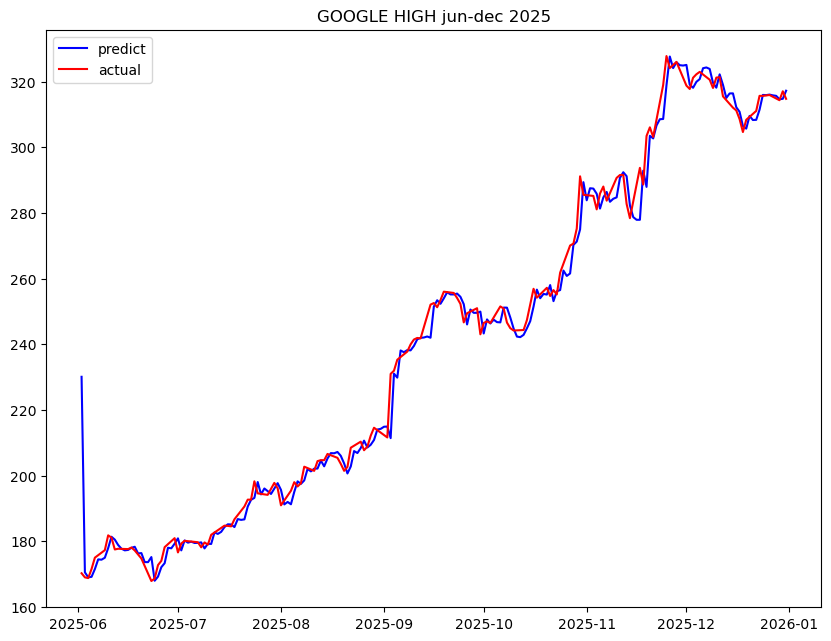

In [80]:
plt.plot(res_VARMA.predict()['High_GOOG'],color='blue', label='predict')
plt.plot(df['High'],color='red', label='actual')
plt.legend(loc='best')
plt.title('GOOGLE HIGH jun-dec 2025')
plt.show()

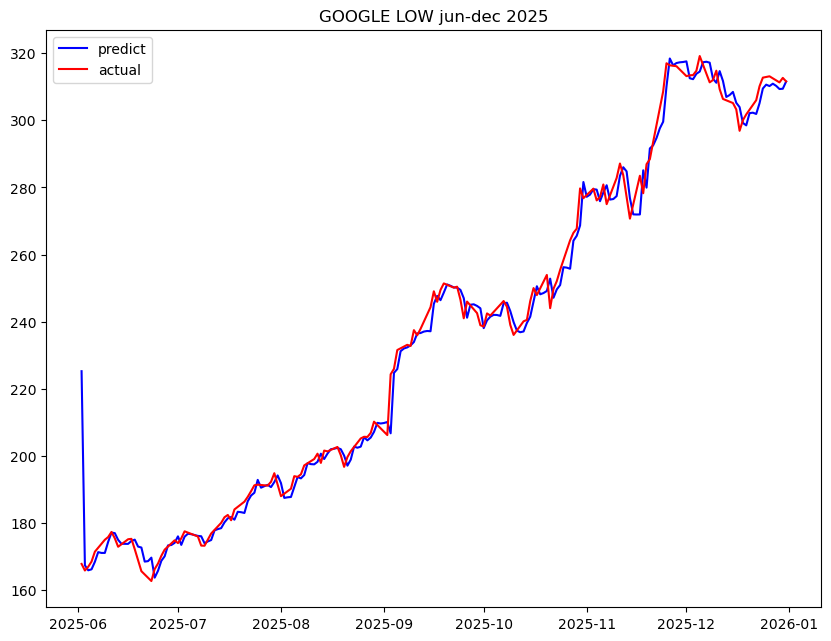

In [81]:
plt.plot(res_VARMA.predict()['Low_GOOG'],color='blue', label='predict')
plt.plot(df['Low'],color='red', label='actual')
plt.legend(loc='best')
plt.title('GOOGLE LOW jun-dec 2025')
plt.show()

In [82]:
endog.index

DatetimeIndex(['2025-06-02', '2025-06-03', '2025-06-04', '2025-06-05',
               '2025-06-06', '2025-06-07', '2025-06-08', '2025-06-09',
               '2025-06-10', '2025-06-11',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=213, freq='D')

In [83]:
res_VARMA.forecast(steps=2)

,High_GOOG,Low_GOOG
2026-01-01,314.415800,309.674742
2026-01-02,314.564048,308.903386


In [84]:
LT = res_VARMA.forecast(steps=20)

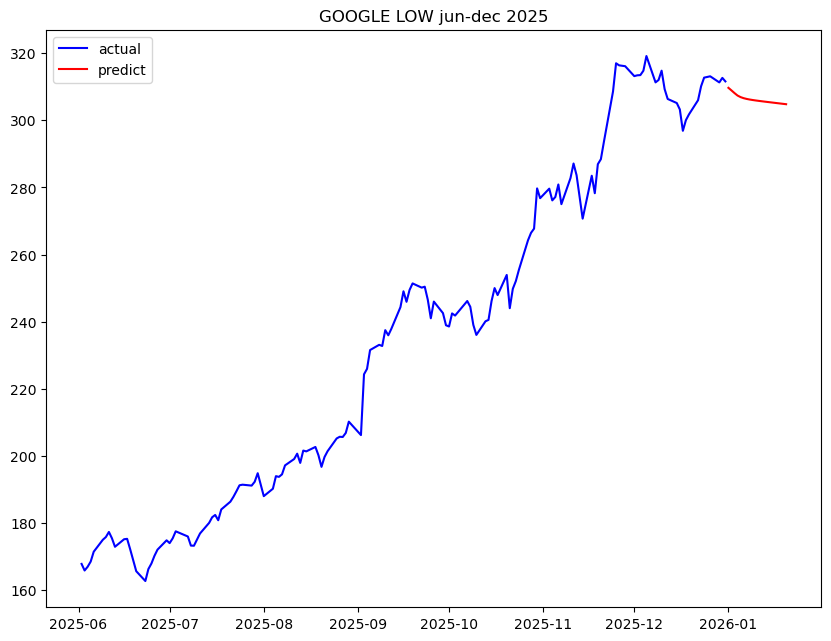

In [85]:
plt.plot(df['Low'],color='blue', label='actual')
plt.plot(LT['Low_GOOG'],color='red', label='predict')
plt.legend(loc='best')
plt.title('GOOGLE LOW jun-dec 2025')
plt.show()

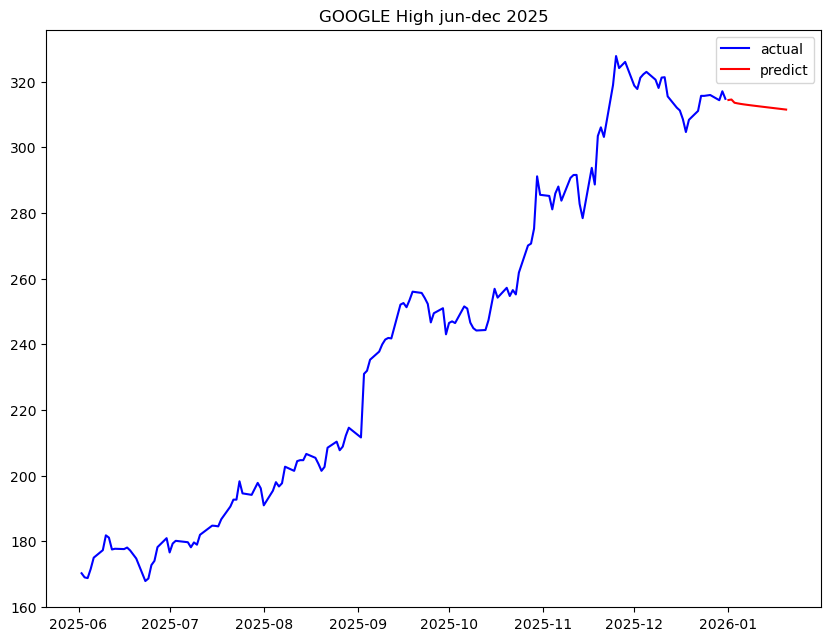

In [86]:
plt.plot(df['High'],color='blue', label='actual')
plt.plot(LT['High_GOOG'],color='red', label='predict')
plt.legend(loc='best')
plt.title('GOOGLE High jun-dec 2025')
plt.show()

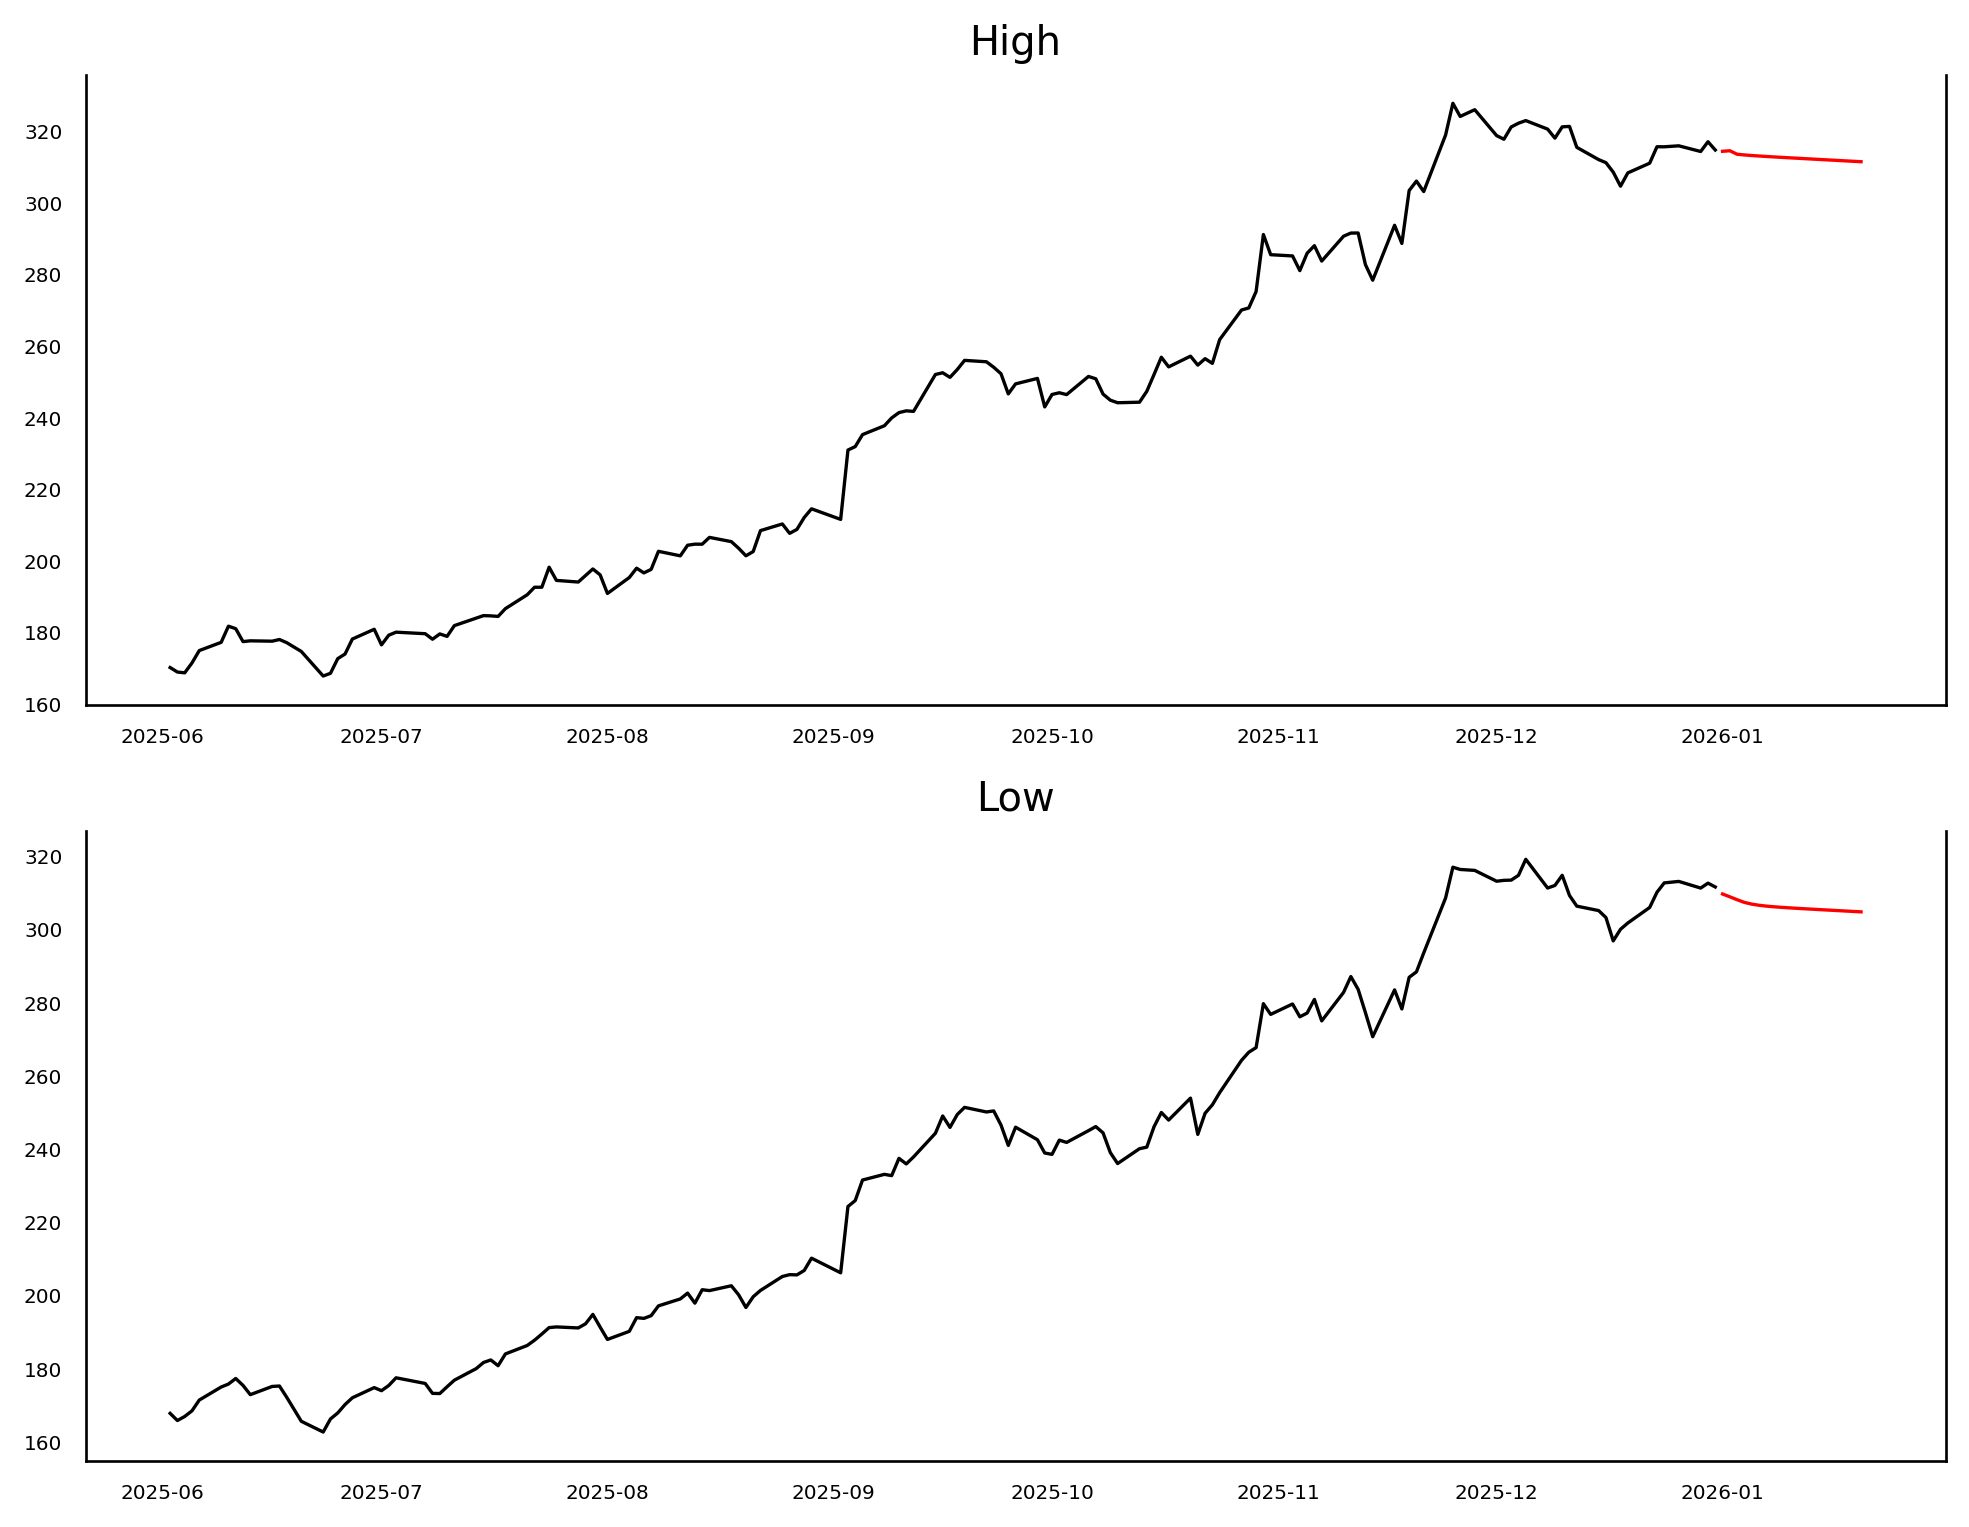

In [115]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(LT['High_GOOG'], color='red', linewidth=1)
ax1.plot(df['High'], color='black', linewidth=1)
ax1.set_title('High')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(LT['Low_GOOG'], color='red', linewidth=1)
ax2.plot(df['Low'], color='black', linewidth=1)
ax2.set_title('Low')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)
plt.show()

# VARMAX 

In [116]:
def optimize_VARMAX(endog, exog, parameters_list):
    """
        Returns a dataframe with (p,q) and MSE
        
        endog - the observed variable
        exog - the exogenous variables
        parameters_list - list of (p,q) tuples
    """
    
    results = []
    
    for param in tqdm_notebook(parameters_list):
        try:
            model = VARMAX(endog, exog, order=param).fit(disp=False)
        except:
            continue
    
        mse = model.mse
        results.append([param, mse])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'mse']
    
    result_df = result_df.sort_values(by='mse', ascending=True).reset_index(drop=True)
    
    return result_df

In [117]:
endog = macro_data[['realgdp', 'realcons']][:200]

exog_cols = macro_data.columns.drop(['year', 'quarter', 'realgdp', 'realcons'])
exog = macro_data[exog_cols][:200]

p = range(0, 4, 1)
q = range(0, 4, 1)

parameters = product(p, q)
parameters_list = list(parameters)

results_df_VARMAX = optimize_VARMAX(endog, exog, parameters_list)
results_df_VARMAX

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",mse
0,"(3, 3)",2327.028728
1,"(1, 3)",2337.719375
2,"(2, 3)",2343.239716
3,"(3, 2)",2364.074001
4,"(2, 2)",2396.060940
5,"(1, 2)",2405.011529
6,"(3, 1)",2465.098225
7,"(3, 0)",2519.674899
8,"(2, 1)",2538.979862
9,"(1, 1)",2575.697526


In [118]:
best_model_VARMAX = VARMAX(endog, exog, order=(3,3))
res_VARMAX = best_model_VARMAX.fit(disp=False)
print(res_VARMAX.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realgdp', 'realcons']   No. Observations:                  200
Model:                         VARMAX(3,3)   Log Likelihood               -1952.043
                               + intercept   AIC                           4002.087
Date:                     Wed, 16 Sep 2026   BIC                           4163.704
Time:                             15:59:39   HQIC                          4067.491
Sample:                                  0                                         
                                     - 200                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             1.24, 0.07   Jarque-Bera (JB):           4.89, 3.40
Prob(Q):                        0.26, 0.79   Prob(JB):                   0.09, 0.18
Heteroskedasticity (H):         1.83, 2.26   Skew:                      0.05

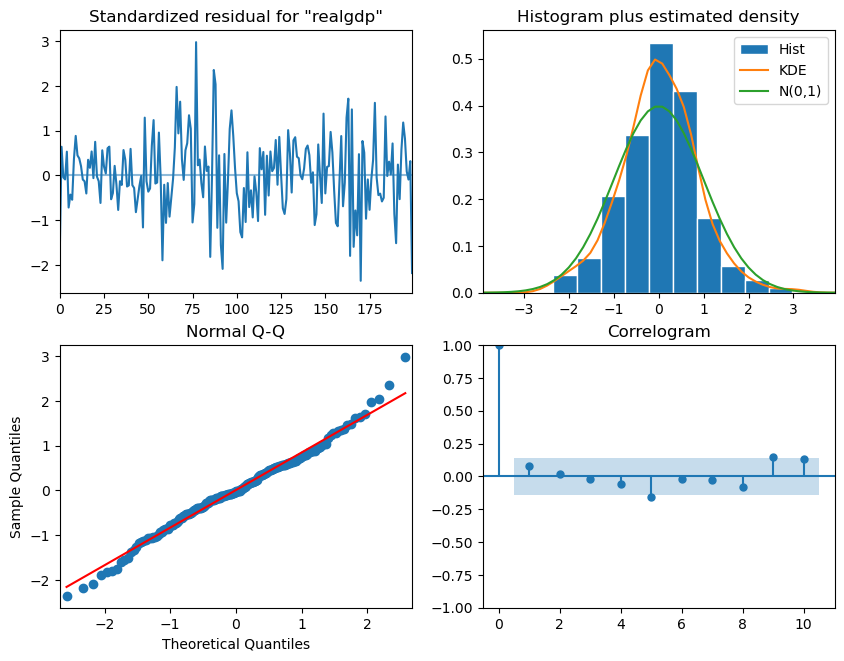

In [122]:
res_VARMAX.plot_diagnostics()

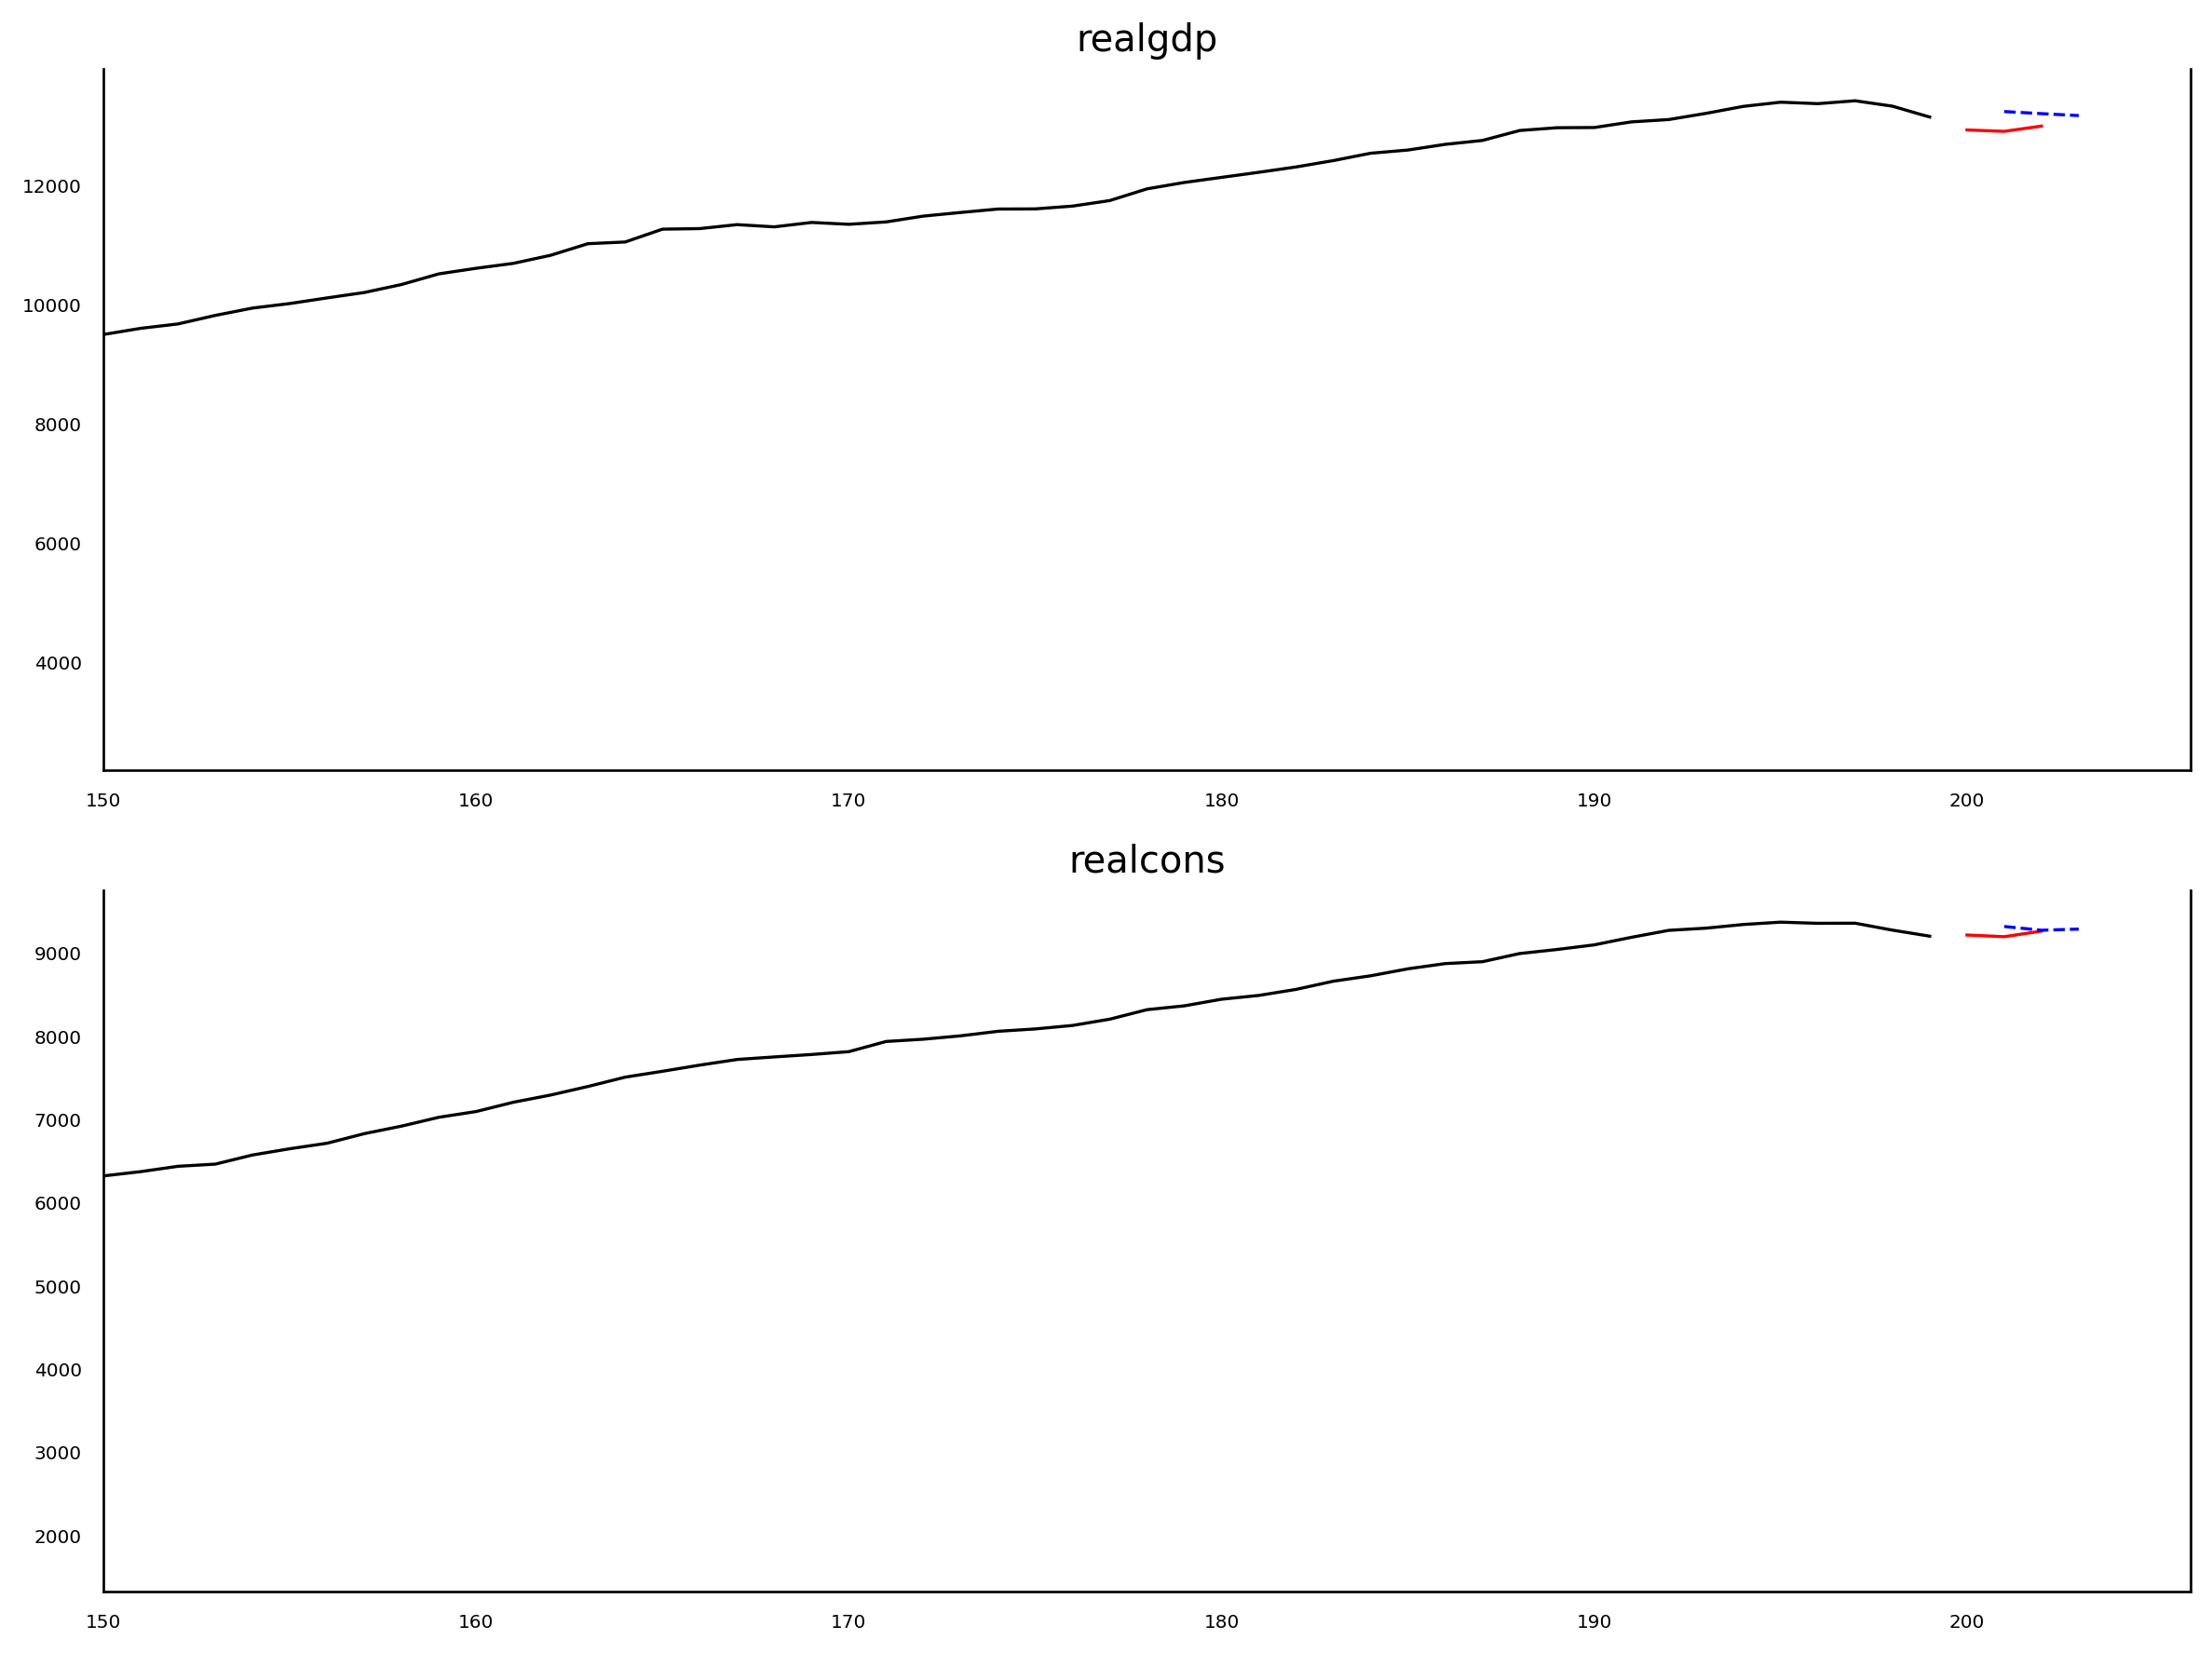

In [124]:
n_forecast = 3
predict = res_VARMAX.get_prediction(end=best_model_VARMAX.nobs + n_forecast, exog = exog.iloc[-4:])
idx = np.arange(len(predict.predicted_mean))

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(macro_data['realgdp'][:200], color='black', linewidth=1)
ax1.plot(macro_data['realgdp'][200:], color='red', linewidth=1)
ax1.plot(idx[-n_forecast:], 
         predict.predicted_mean['realgdp'][-n_forecast:], 
         color='blue', 
         ls='--',
         linewidth=1)
ax1.set_title('realgdp')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.set_xlim(150, 206)
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(macro_data['realcons'][:200], color='black', linewidth=1)
ax2.plot(macro_data['realcons'][200:], color='red', linewidth=1)
ax2.plot(idx[-n_forecast:], 
         predict.predicted_mean['realcons'][-n_forecast:], 
         color='blue', 
         ls='--',
         linewidth=1)
ax2.set_title('realcons')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.set_xlim(150, 206)
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

## Ejemplo anterior con series de tiempo

In [125]:
macro_data = sm.datasets.macrodata.load_pandas()
macro_data = macro_data.data
macro_data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [126]:
endog = macro_data[['realgdp', 'realcons']][:200]
endog

,realgdp,realcons
0,2710.349,1707.4
1,2778.801,1733.7
2,2775.488,1751.8
3,2785.204,1753.7
4,2847.699,1770.5
...,...,...
195,13391.249,9363.6
196,13366.865,9349.6
197,13415.266,9351.0
198,13324.600,9267.7


In [128]:
time_index = pd.date_range(start="1959-01-01", periods=len(endog), freq="Q")
time_index

DatetimeIndex(['1959-03-31', '1959-06-30', '1959-09-30', '1959-12-31',
               '1960-03-31', '1960-06-30', '1960-09-30', '1960-12-31',
               '1961-03-31', '1961-06-30',
               ...
               '2006-09-30', '2006-12-31', '2007-03-31', '2007-06-30',
               '2007-09-30', '2007-12-31', '2008-03-31', '2008-06-30',
               '2008-09-30', '2008-12-31'],
              dtype='datetime64[ns]', length=200, freq='QE-DEC')

In [129]:
endog['time_column'] = pd.to_datetime(time_index)

In [130]:
endog

,realgdp,realcons,time_column
0,2710.349,1707.4,1959-03-31
1,2778.801,1733.7,1959-06-30
2,2775.488,1751.8,1959-09-30
3,2785.204,1753.7,1959-12-31
4,2847.699,1770.5,1960-03-31
...,...,...,...
195,13391.249,9363.6,2007-12-31
196,13366.865,9349.6,2008-03-31
197,13415.266,9351.0,2008-06-30
198,13324.600,9267.7,2008-09-30


In [131]:
endog.set_index('time_column', inplace=True)

In [132]:
endog

,realgdp,realcons
time_column,,
1959-03-31,2710.349,1707.4
1959-06-30,2778.801,1733.7
1959-09-30,2775.488,1751.8
1959-12-31,2785.204,1753.7
1960-03-31,2847.699,1770.5
...,...,...
2007-12-31,13391.249,9363.6
2008-03-31,13366.865,9349.6
2008-06-30,13415.266,9351.0


In [134]:
exog_cols = macro_data.columns.drop(['year', 'quarter', 'realgdp', 'realcons'])
exog = macro_data[exog_cols][:200]
exog

,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...
195,2123.426,925.110,9886.2,212.495,1377.4,3.01,4.8,303.204,6.38,-3.37
196,2082.886,943.372,9826.8,213.997,1384.0,1.56,4.9,303.803,2.82,-1.26
197,2026.518,961.280,10059.0,218.610,1409.3,1.74,5.4,304.483,8.53,-6.79
198,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33


In [135]:
exog['time_column'] = pd.to_datetime(time_index)

In [136]:
exog.set_index('time_column', inplace=True)

In [137]:
exog

,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
time_column,,,,,,,,,,
1959-03-31,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...
2007-12-31,2123.426,925.110,9886.2,212.495,1377.4,3.01,4.8,303.204,6.38,-3.37
2008-03-31,2082.886,943.372,9826.8,213.997,1384.0,1.56,4.9,303.803,2.82,-1.26
2008-06-30,2026.518,961.280,10059.0,218.610,1409.3,1.74,5.4,304.483,8.53,-6.79


In [138]:
def optimize_VARMAX(endog, exog, parameters_list):
    """
        Returns a dataframe with (p,q) and MSE
        
        endog - the observed variable
        exog - the exogenous variables
        parameters_list - list of (p,q) tuples
    """
    
    results = []
    
    for param in tqdm_notebook(parameters_list):
        try:
            model = VARMAX(endog, exog, order=param).fit(disp=False)
        except:
            continue
    
        mse = model.mse
        results.append([param, mse])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'mse']
    
    result_df = result_df.sort_values(by='mse', ascending=True).reset_index(drop=True)
    
    return result_df

In [139]:
p = range(0, 4, 1)
q = range(0, 4, 1)

parameters = product(p, q)
parameters_list = list(parameters)

results_df_VARMAX = optimize_VARMAX(endog, exog, parameters_list)
results_df_VARMAX

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",mse
0,"(3, 3)",2327.028728
1,"(1, 3)",2337.719375
2,"(2, 3)",2343.239716
3,"(3, 2)",2364.074001
4,"(2, 2)",2396.060940
5,"(1, 2)",2405.011529
6,"(3, 1)",2465.098225
7,"(3, 0)",2519.674899
8,"(2, 1)",2538.979862
9,"(1, 1)",2575.697526


In [140]:
best_model_VARMAX = VARMAX(endog, exog, order=(3,3))
res_VARMAX = best_model_VARMAX.fit(disp=False)
print(res_VARMAX.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realgdp', 'realcons']   No. Observations:                  200
Model:                         VARMAX(3,3)   Log Likelihood               -1952.043
                               + intercept   AIC                           4002.087
Date:                     Wed, 16 Sep 2026   BIC                           4163.704
Time:                             20:08:53   HQIC                          4067.491
Sample:                         03-31-1959                                         
                              - 12-31-2008                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             1.24, 0.07   Jarque-Bera (JB):           4.89, 3.40
Prob(Q):                        0.26, 0.79   Prob(JB):                   0.09, 0.18
Heteroskedasticity (H):         1.83, 2.26   Skew:                      0.05

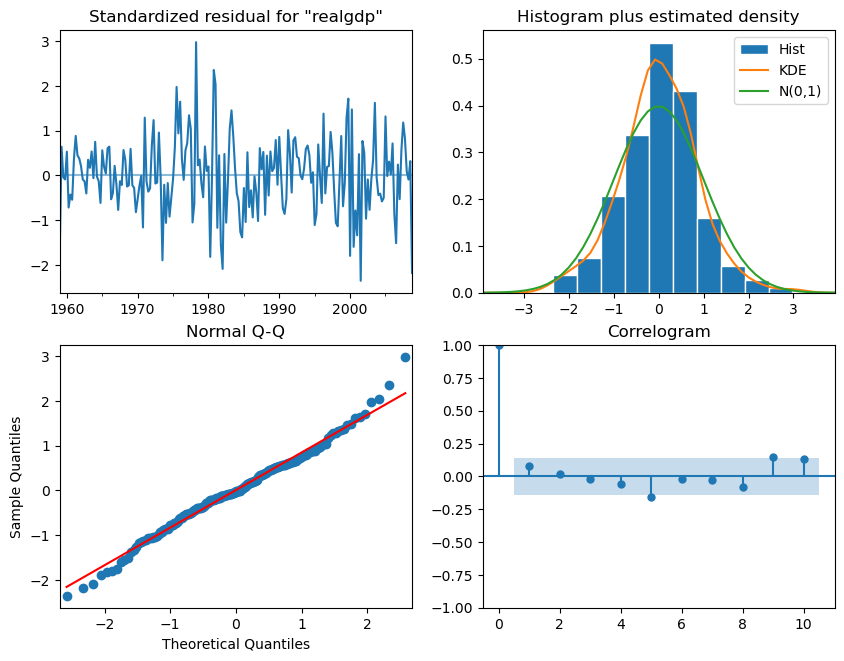

In [141]:
res_VARMAX.plot_diagnostics()

In [143]:
res_VARMAX.resid

,realgdp,realcons
time_column,,
1959-03-31,-118.275438,-101.016920
1959-06-30,30.604138,-20.657110
1959-09-30,-2.022536,14.260709
1959-12-31,-4.000057,2.969596
1960-03-31,23.771830,-3.575417
...,...,...
2007-12-31,36.664487,1.985923
2008-03-31,3.893962,4.194895
2008-06-30,-4.105300,-70.515237


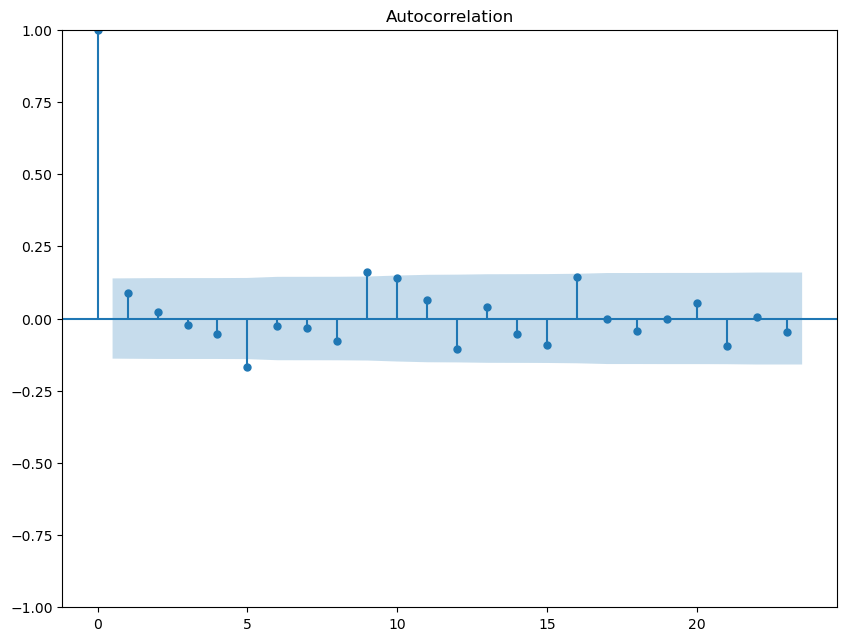

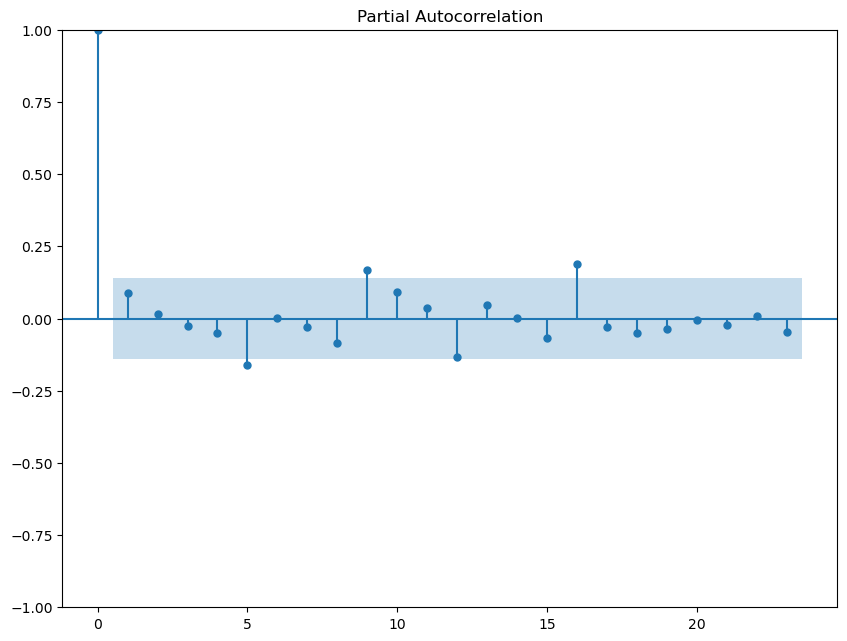

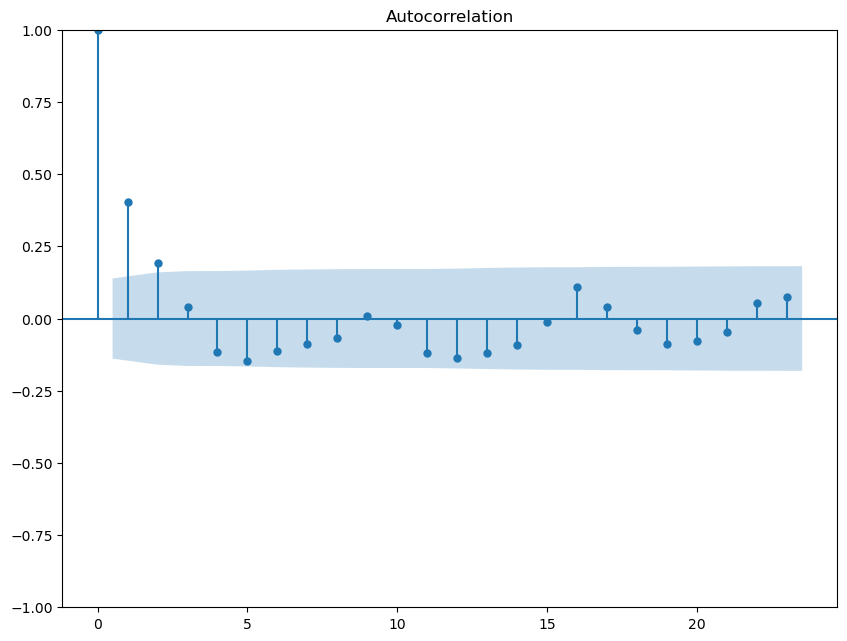

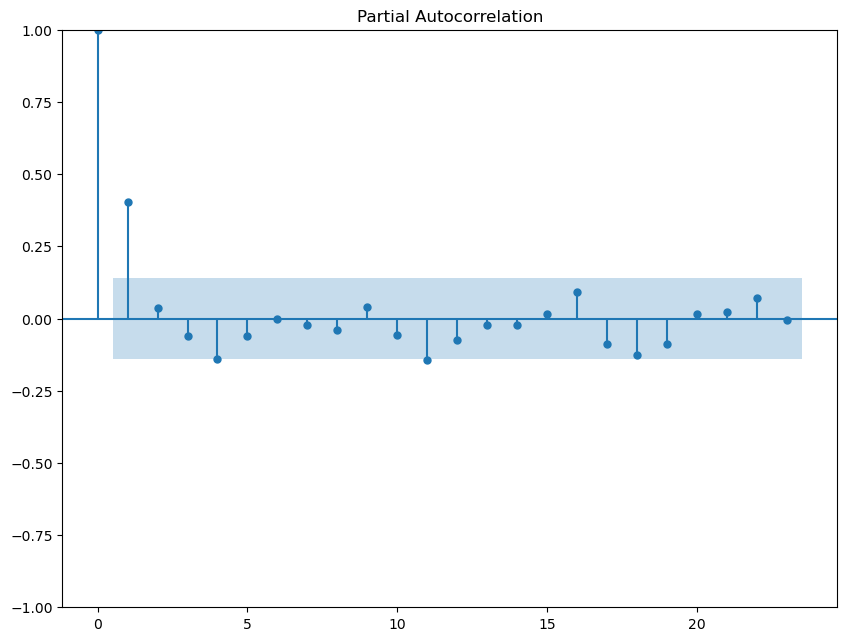

In [148]:
plot_acf(res_VARMAX.resid['realgdp'][1:])
plot_pacf(res_VARMAX.resid['realgdp'][1:])
plot_acf(res_VARMAX.resid['realcons'][1:])
plot_pacf(res_VARMAX.resid['realcons'][1:])
plt.show()

In [153]:
res_VARMAX.forecast(steps=2,exog=exog.iloc[-2:])

,realgdp,realcons
2009-03-31,13116.570596,9214.777266
2009-06-30,13052.424325,9200.120394


In [154]:
exog.iloc[-2:]

,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
time_column,,,,,,,,,,
2008-09-30,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
2008-12-31,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91


In [155]:
LT = res_VARMAX.forecast(steps=20,exog=exog.iloc[-20:])

In [156]:
LT

,realgdp,realcons
2009-03-31,12731.806442,8978.118974
2009-06-30,12567.634811,8905.064458
2009-09-30,12466.921028,8829.639556
2009-12-31,12501.494297,8848.371854
2010-03-31,12498.473003,8802.331514
2010-06-30,12543.131026,8811.791338
2010-09-30,12610.072382,8830.806625
2010-12-31,12687.991917,8862.107855
2011-03-31,12823.569138,8949.828534
2011-06-30,12937.122978,9023.368722


In [157]:
res_VARMAX.predict()

,realgdp,realcons
1959-03-31,2828.624438,1808.416920
1959-06-30,2748.196862,1754.357110
1959-09-30,2777.510536,1737.539291
1959-12-31,2789.204057,1750.730404
1960-03-31,2823.927170,1774.075417
...,...,...
2007-12-31,13354.584513,9361.614077
2008-03-31,13362.971038,9345.405105
2008-06-30,13419.371300,9421.515237
2008-09-30,13310.321172,9316.759882


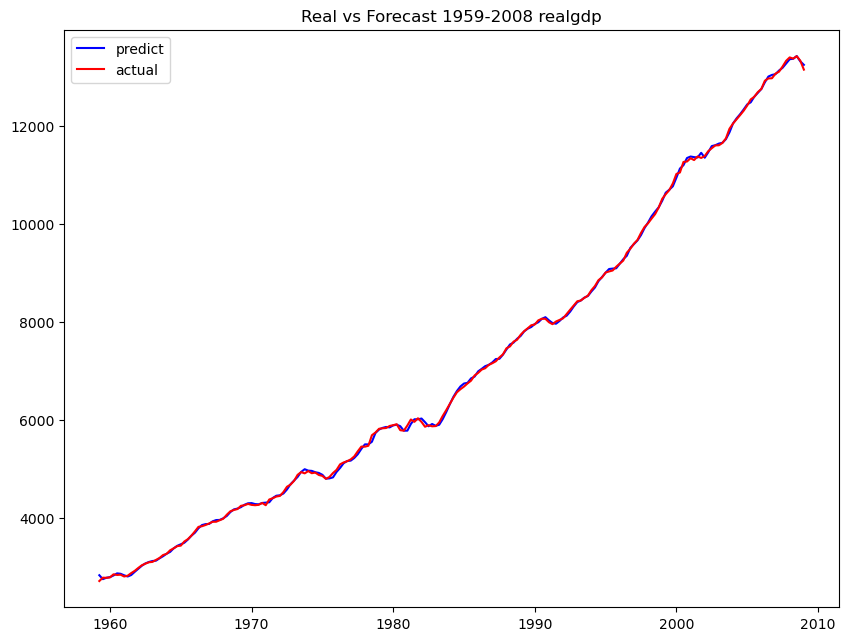

In [160]:
plt.plot(res_VARMAX.predict()['realgdp'],color='blue', label='predict')
plt.plot(endog['realgdp'],color='red', label='actual')
plt.legend(loc='best')
plt.title('Real vs Forecast 1959-2008 realgdp')
plt.show()

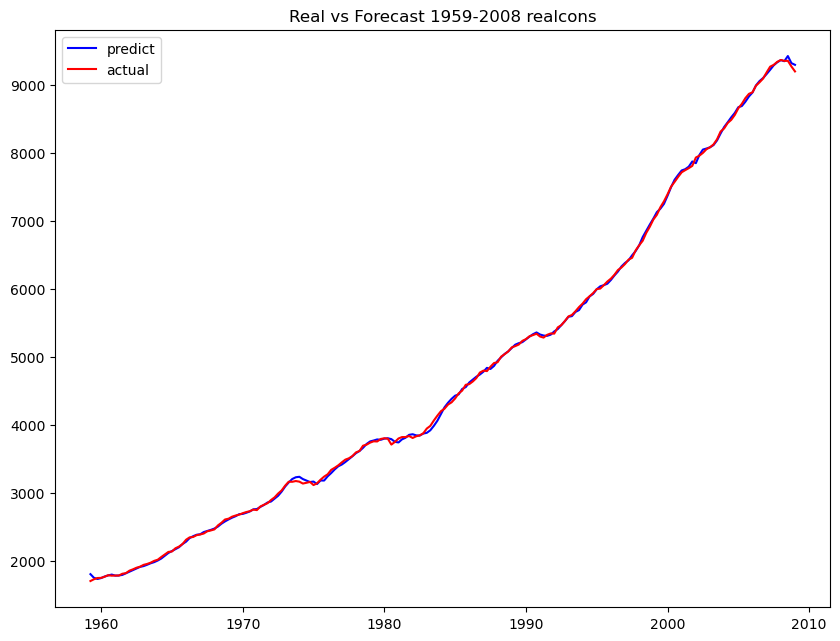

In [161]:
plt.plot(res_VARMAX.predict()['realcons'],color='blue', label='predict')
plt.plot(endog['realcons'],color='red', label='actual')
plt.legend(loc='best')
plt.title('Real vs Forecast 1959-2008 realcons')
plt.show()

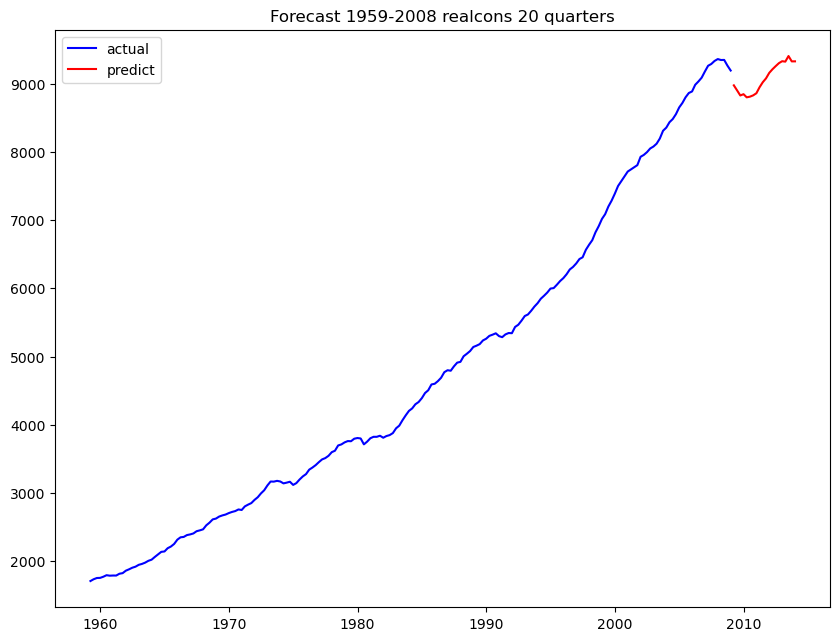

In [162]:
plt.plot(endog['realcons'],color='blue', label='actual')
plt.plot(LT['realcons'],color='red', label='predict')
plt.legend(loc='best')
plt.title('Forecast 1959-2008 realcons 20 quarters')
plt.show()

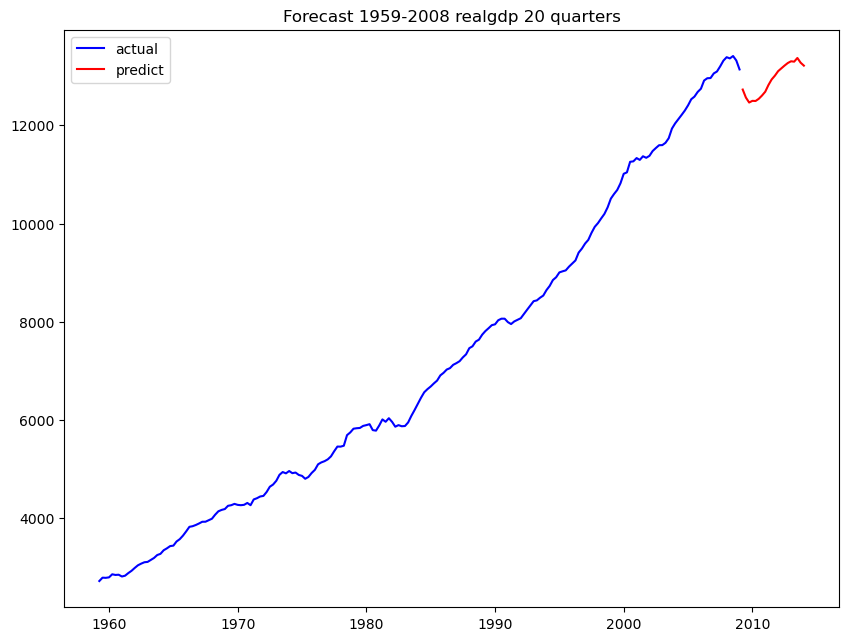

In [163]:
plt.plot(endog['realgdp'],color='blue', label='actual')
plt.plot(LT['realgdp'],color='red', label='predict')
plt.legend(loc='best')
plt.title('Forecast 1959-2008 realgdp 20 quarters')
plt.show()

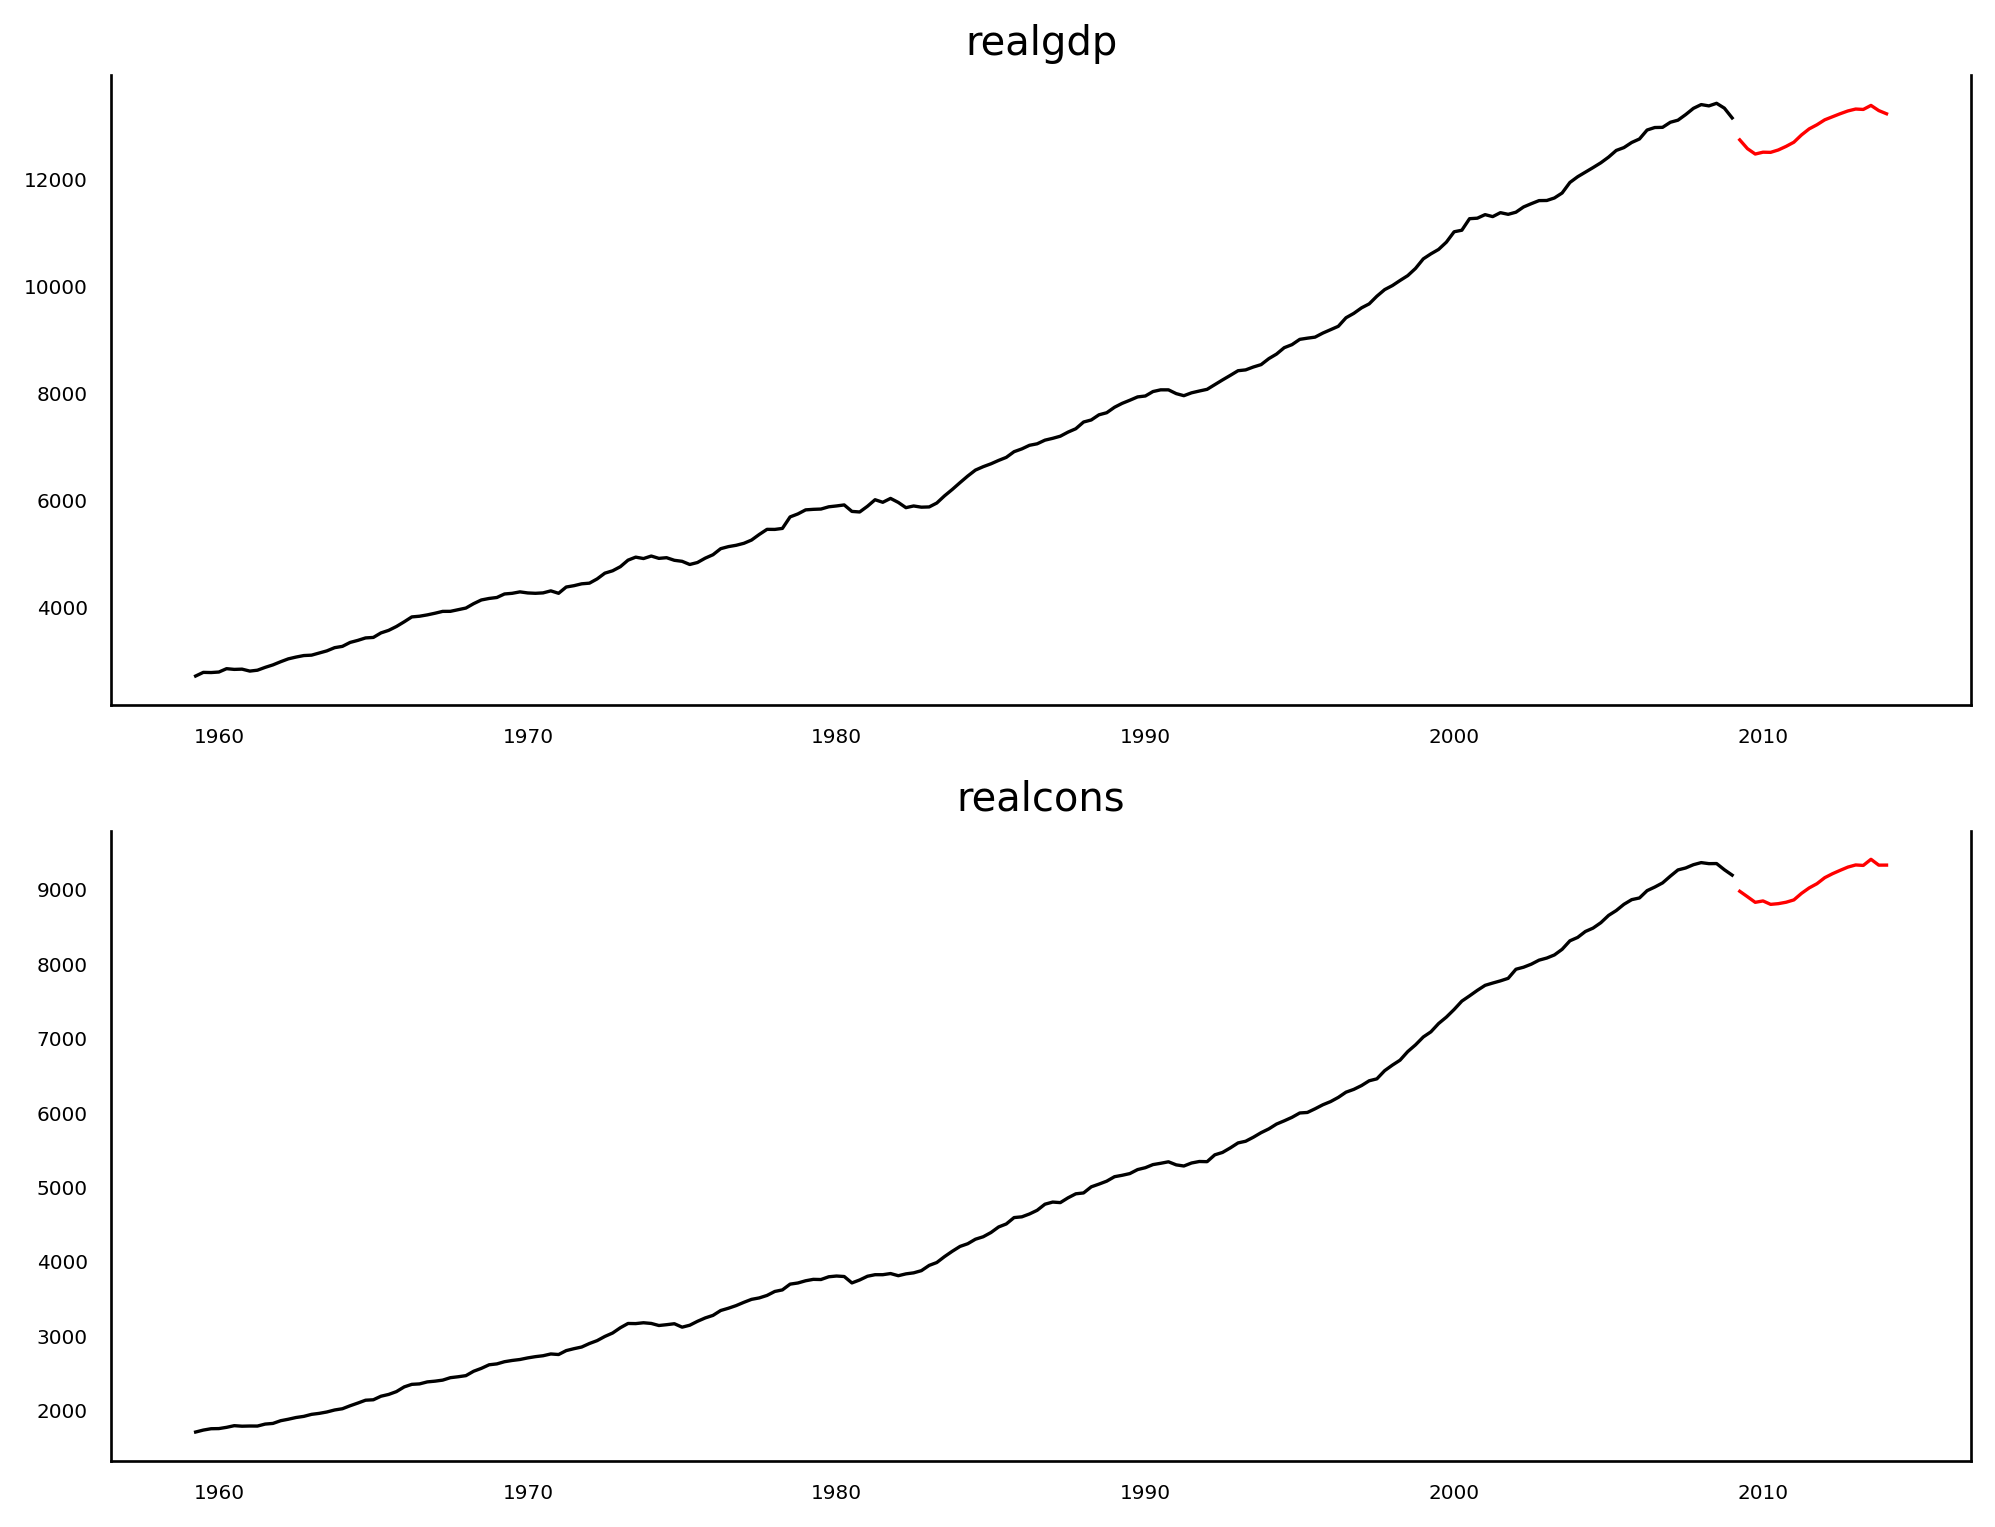

In [164]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, dpi=240)

ax1.plot(LT['realgdp'], color='red', linewidth=1)
ax1.plot(endog['realgdp'], color='black', linewidth=1)
ax1.set_title('realgdp')
ax1.xaxis.set_ticks_position('none')
ax1.yaxis.set_ticks_position('none')
ax1.spines['top'].set_alpha(0)
ax1.tick_params(labelsize=6)

ax2.plot(LT['realcons'], color='red', linewidth=1)
ax2.plot(endog['realcons'], color='black', linewidth=1)
ax2.set_title('realcons')
ax2.xaxis.set_ticks_position('none')
ax2.yaxis.set_ticks_position('none')
ax2.spines['top'].set_alpha(0)
ax2.tick_params(labelsize=6)
plt.show()